# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 18     |  |
| :-------------|:-------------|
| Tim Mekkelholt| 6224687 |
| Laura Otto | 6488463 |
| Justin Sloots | 6541313 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Tim', 'Laura','Justin']

## Opdracht 1: Planning.

| Planning Groep: 18     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibratie sensor gedaan | 11:30 |
| Eerste testmeting gedaan | 12:00 |
| Meetplan uitwerken | 12:00-12:30 |
| Optestellen/eerste meting| 13:45-14:45 |
| Iteraties uitvoeren | 15:00-16:30 |
| Algoritme presenteren | 16:30-17:00 |
| Afronden en opruimen | 17:00-17:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 14:45-15:00 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit
# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep 18
<img src="Kalibratieopstelling.jpg" width="400">

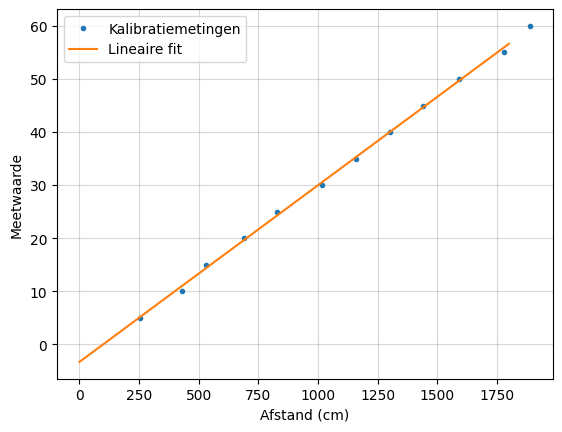

De parameters van de lineaire fit zijn: a = 0.0333, b = -3.33


In [3]:
# verwerk hier jullie kalibratiemetingen
afstanden = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60])
meetwaarden = np.array([253, 430, 530, 690, 830, 1015, 1160, 1300, 1440, 1590, 1780, 1890])

def line (x, a, b):
    return a*x + b
x_fit = np.linspace(0, 1800, 1000)

popt, pcov = curve_fit(line, meetwaarden, afstanden)


plt.figure()
plt.plot( meetwaarden,afstanden, '.', label='Kalibratiemetingen')
plt.plot( x_fit, line(x_fit, popt[0], popt[1]), label='Lineaire fit')
plt.xlabel('Afstand (cm)')  
plt.ylabel('Meetwaarde')
plt.grid(alpha=0.5)
plt.legend()
plt.show()
print(f"De parameters van de lineaire fit zijn: a = {popt[0]:.4f}, b = {popt[1]:.2f}")



## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  45.0
1   0  30   0  20  43.5
2  40   0  30   0  48.5
3  30   0  20   0  46.2


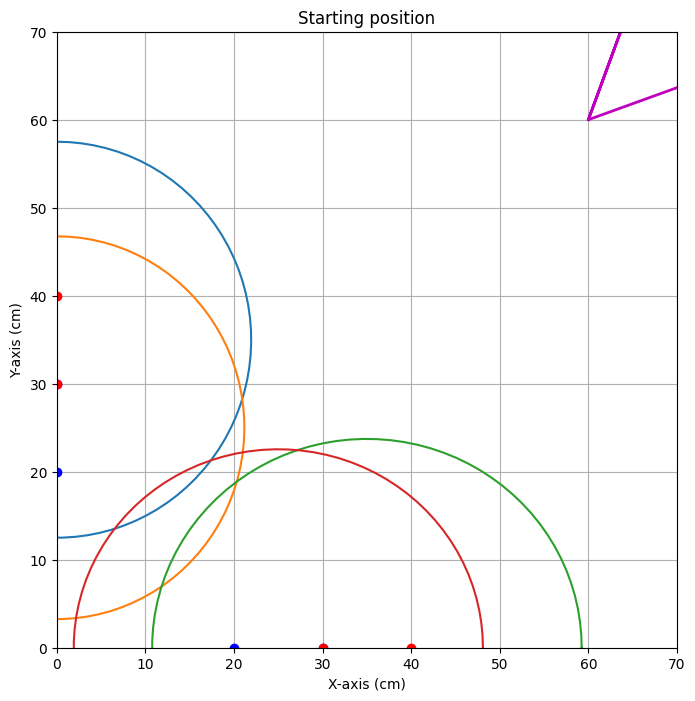


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=96.155


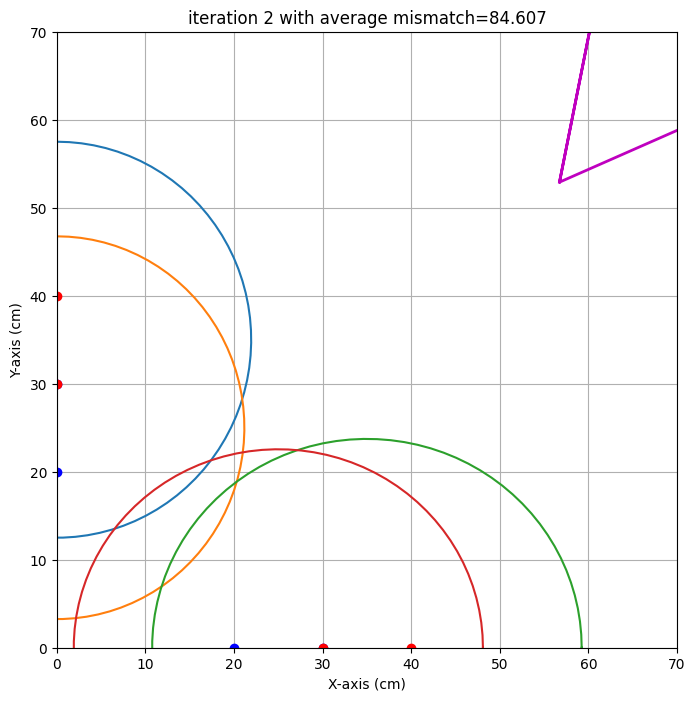

end iteration 2 with average mismatch=84.607


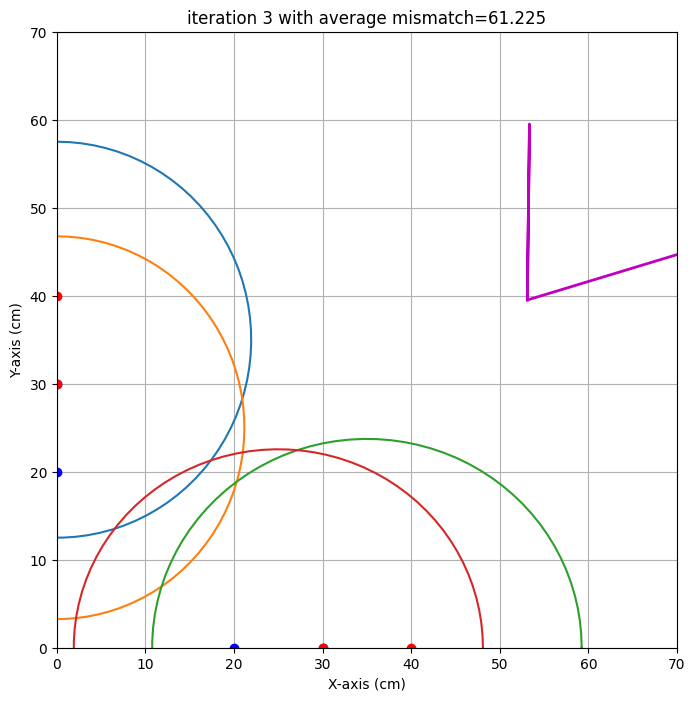

end iteration 3 with average mismatch=61.225


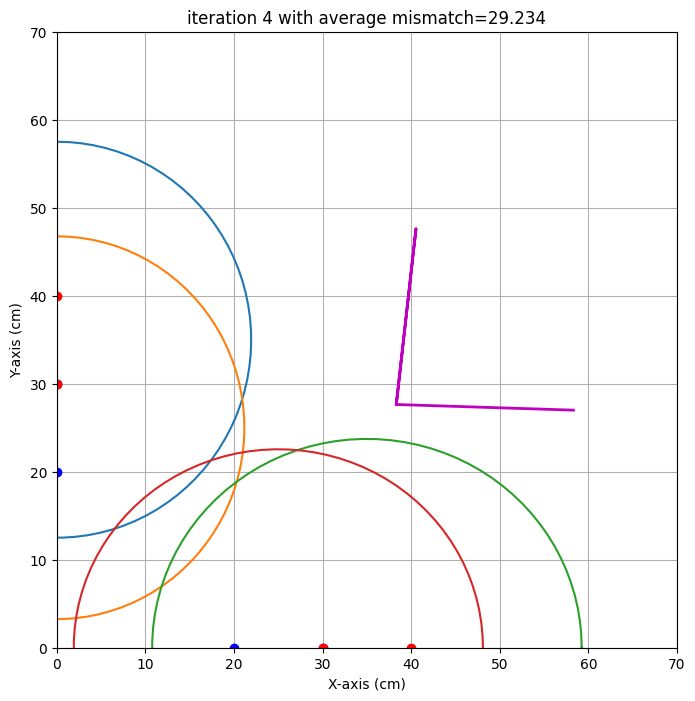

end iteration 4 with average mismatch=29.234


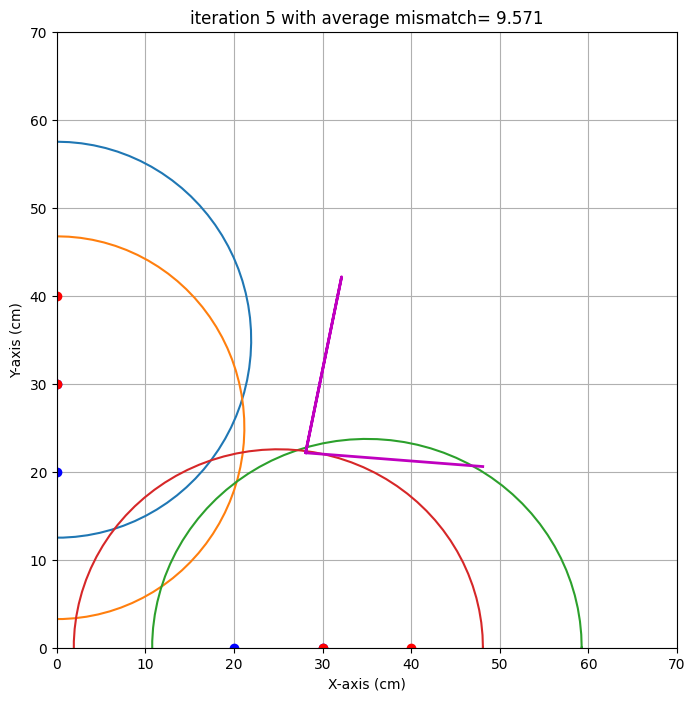

end iteration 5 with average mismatch= 9.571


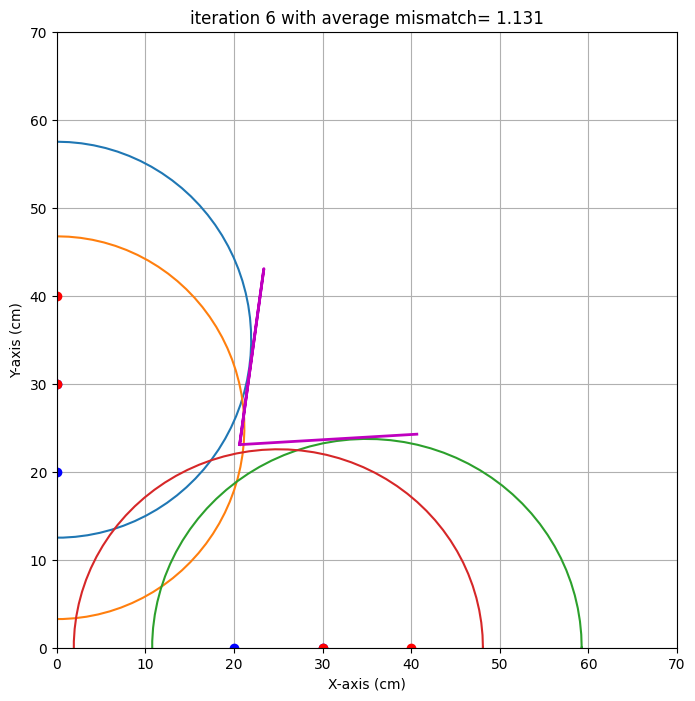

end iteration 6 with average mismatch= 1.131


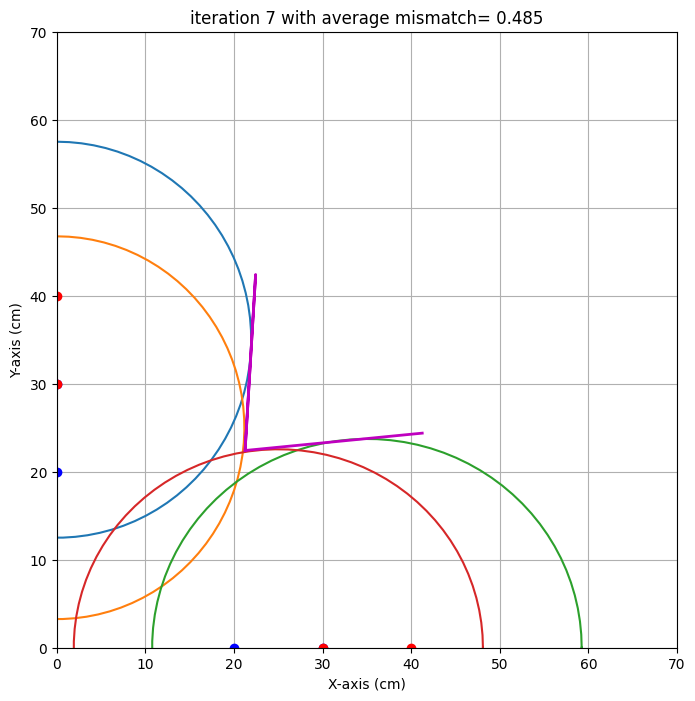

end iteration 7 with average mismatch= 0.485
end iteration 8 with average mismatch= 0.462


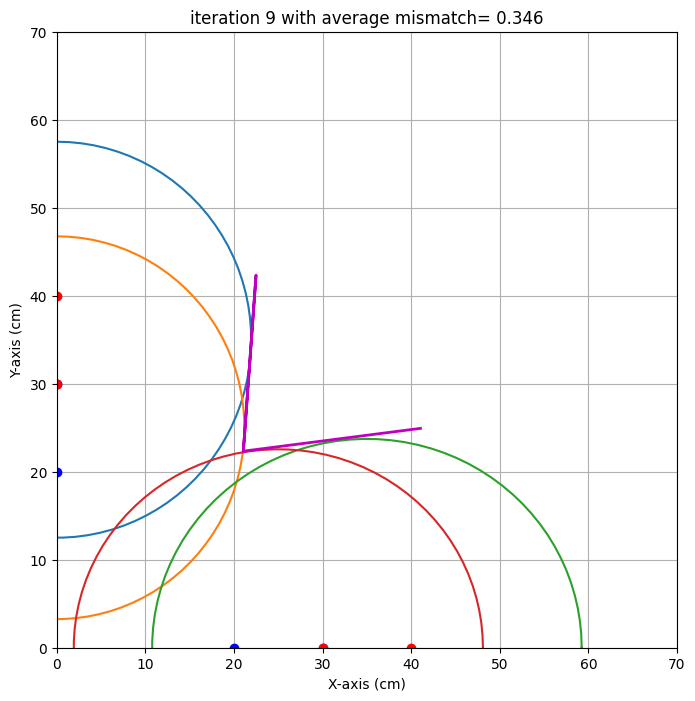

end iteration 9 with average mismatch= 0.346


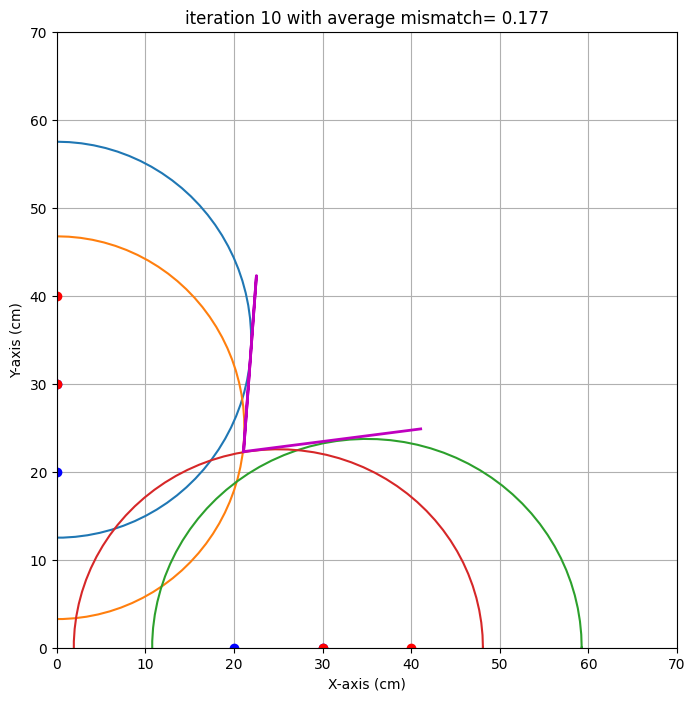

end iteration 10 with average mismatch= 0.177
end iteration 11 with average mismatch= 0.171
end iteration 12 with average mismatch= 0.169
end iteration 13 with average mismatch= 0.168
end iteration 14 with average mismatch= 0.168
end iteration 15 with average mismatch= 0.168
end iteration 16 with average mismatch= 0.168
end iteration 17 with average mismatch= 0.168
end iteration 18 with average mismatch= 0.168
end iteration 19 with average mismatch= 0.168
end iteration 20 with average mismatch= 0.168
end iteration 21 with average mismatch= 0.168
end iteration 22 with average mismatch= 0.166


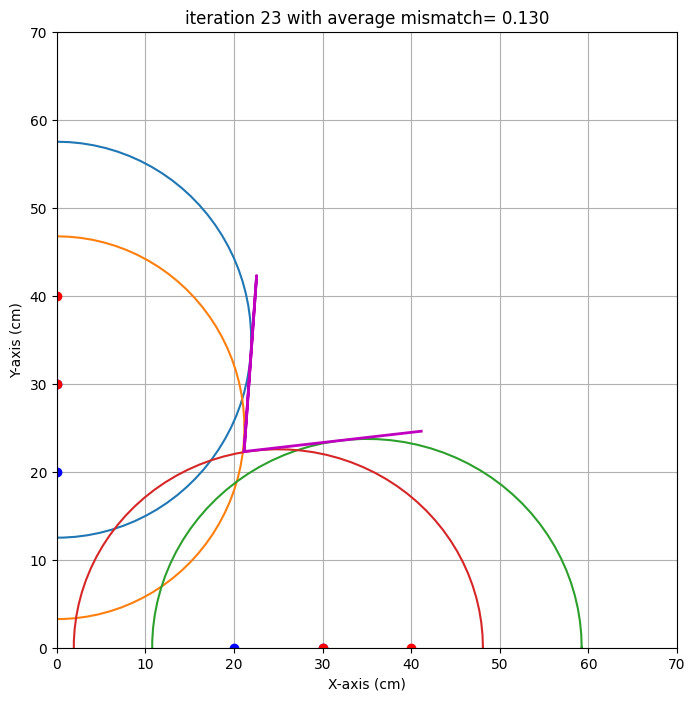

end iteration 23 with average mismatch= 0.130


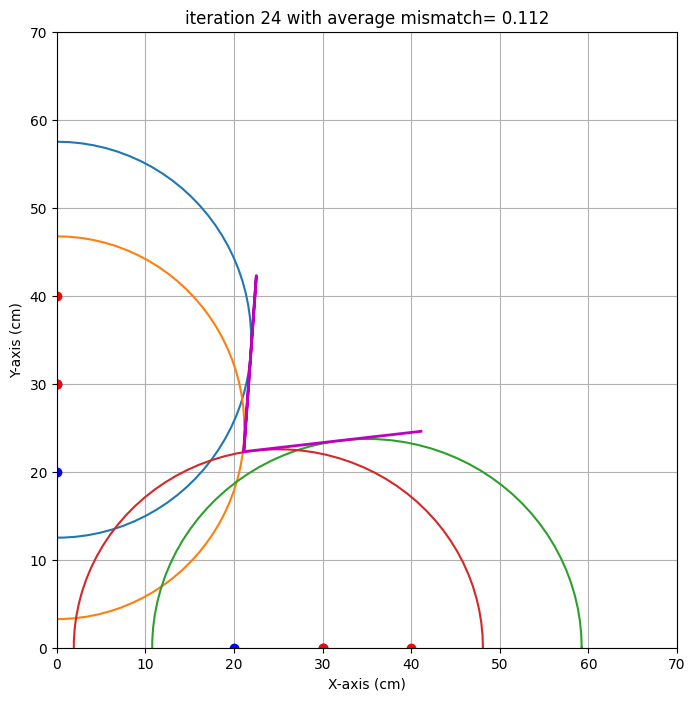

end iteration 24 with average mismatch= 0.112
end iteration 25 with average mismatch= 0.108
end iteration 26 with average mismatch= 0.108
end iteration 27 with average mismatch= 0.108
end iteration 28 with average mismatch= 0.108
end iteration 29 with average mismatch= 0.108
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.108
###############################################################################
end of iteration  30
Best alpha=   6.59 with uncertainty=   0.00
Best beta =   4.05 with uncertainty=   0.00
Best x0   =  21.09 with uncertainty=   0.00
Best y0   =  22.28 with uncertainty=   0.00
###############################################################################
no uncertainty found, please run again


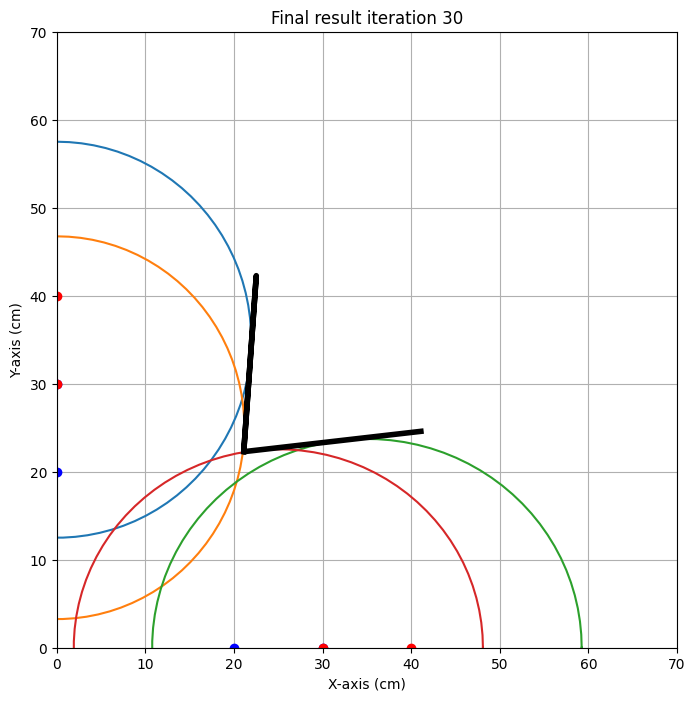

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,45.0],
    [0,30,0,20,43.5],
    #[0,10,0,20,135.0],
    [40,0,30,0,48.5],
    [30,0,20,0,46.2],
    #[10,0,20,0,190],
    #[10,0,0,10,150]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.1 cm met een standaardafwijking van 0.0 cm 
y0: 22.3 cm met een standaardafwijking van 0.0 cm 
alpha: 6.6 graden met een standaardafwijking van 0.0 graad 
beta: 4.0 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme Justin
<img src="algoritme3.jpg" width="400">

#### algoritme Laura
<img src="Algoritme2.jpg" width="400">

#### algoritme Tim
<img src="Algoritme1.jpg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 29,
           'y0': 43,
           'alpha' : 0, 
           'beta' : 29, 
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Tim' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40, 0, 30, 0, 87.0],
    [35, 0, 25, 0, 86.5],
    [0, 68, 0, 58, 67.0],
    [0, 66, 0, 56, 84.0],
    ]),
       'Laura' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [42, 0, 33, 0, 86.0],
    [47, 0, 38, 0, 84.2],
    [0, 51, 0, 68, 73],
    [0, 52, 0, 67, 71]
    ]),
       'Justin' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [20, 0, 30, 0, 86.7],
    [25, 0, 35, 0, 85.0],
    [0, 52, 0, 62, 66],
    [0, 57, 0, 67, 66],
    ])
      }

## Opdracht 7: Evaluatie.

Tim
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  30   0  87.0
1  35   0  25   0  86.5
2   0  68   0  58  67.0
3   0  66   0  56  84.0


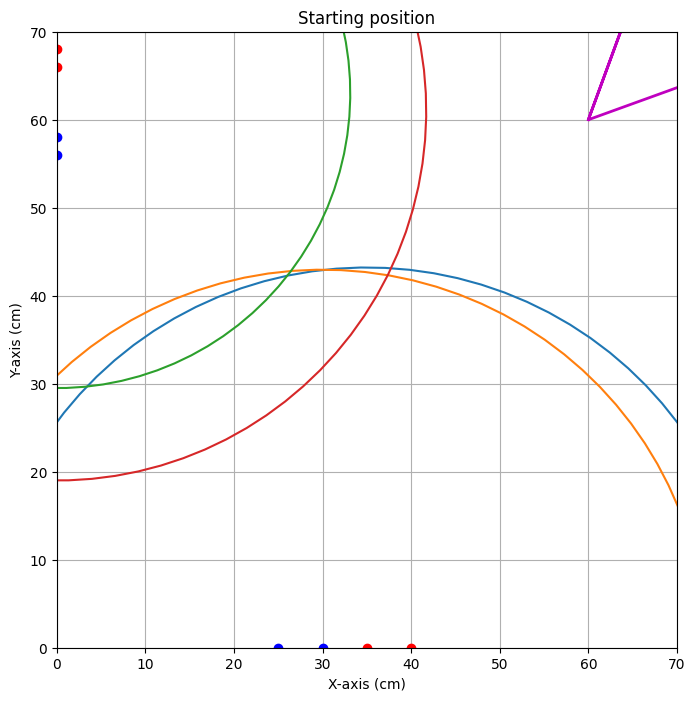


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=50.386


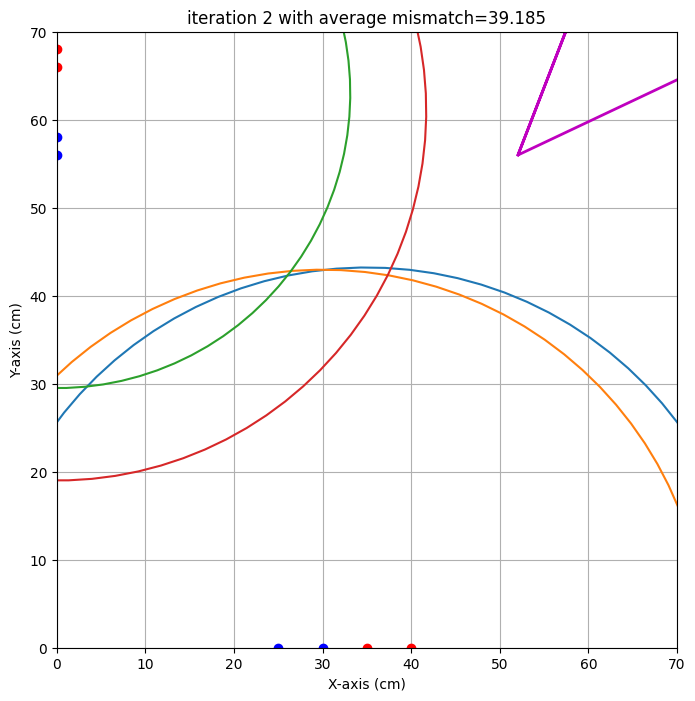

end iteration 2 with average mismatch=39.185


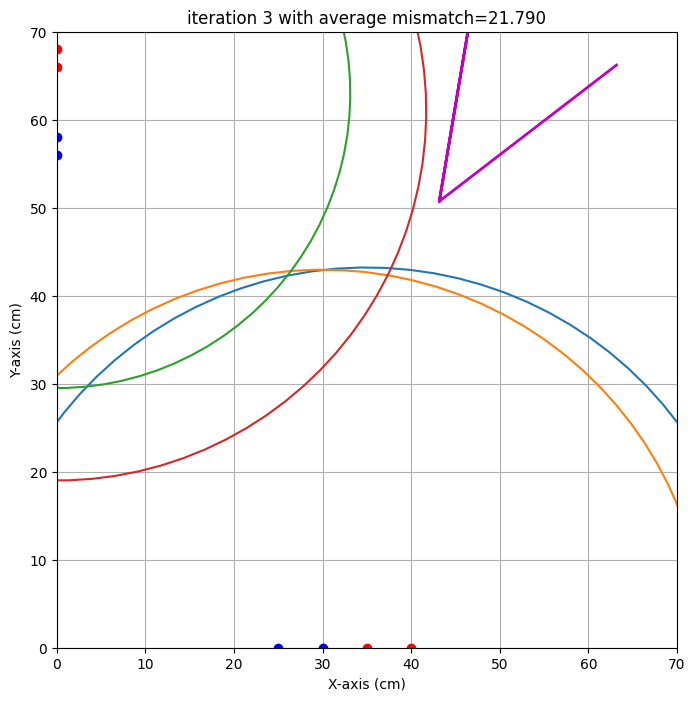

end iteration 3 with average mismatch=21.790


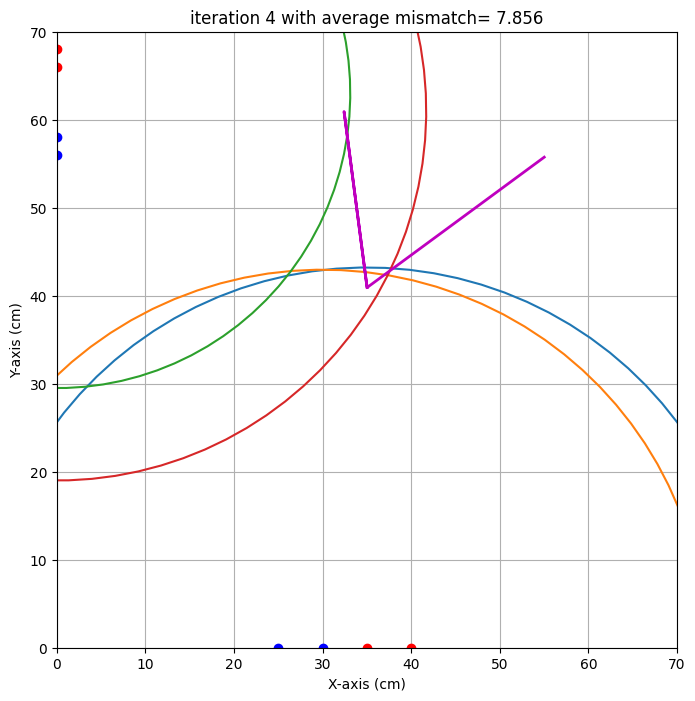

end iteration 4 with average mismatch= 7.856


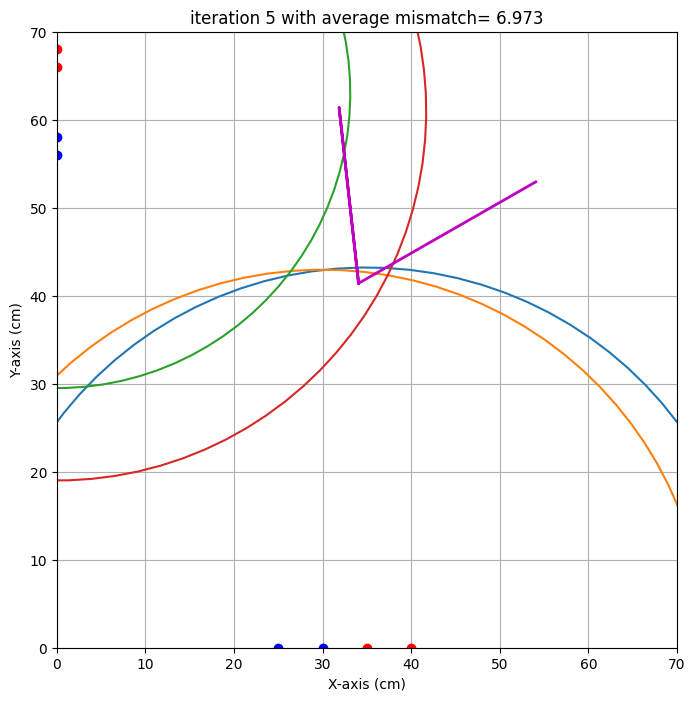

end iteration 5 with average mismatch= 6.973


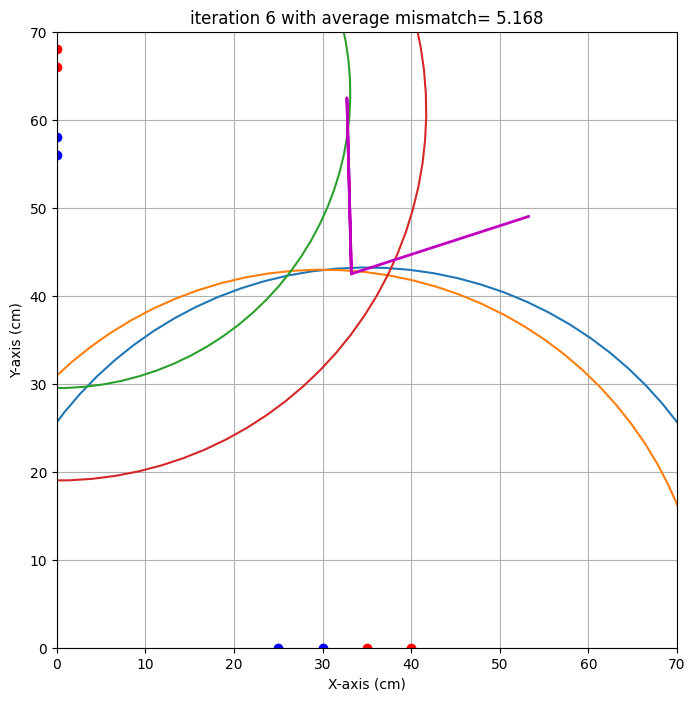

end iteration 6 with average mismatch= 5.168
end iteration 7 with average mismatch= 5.154


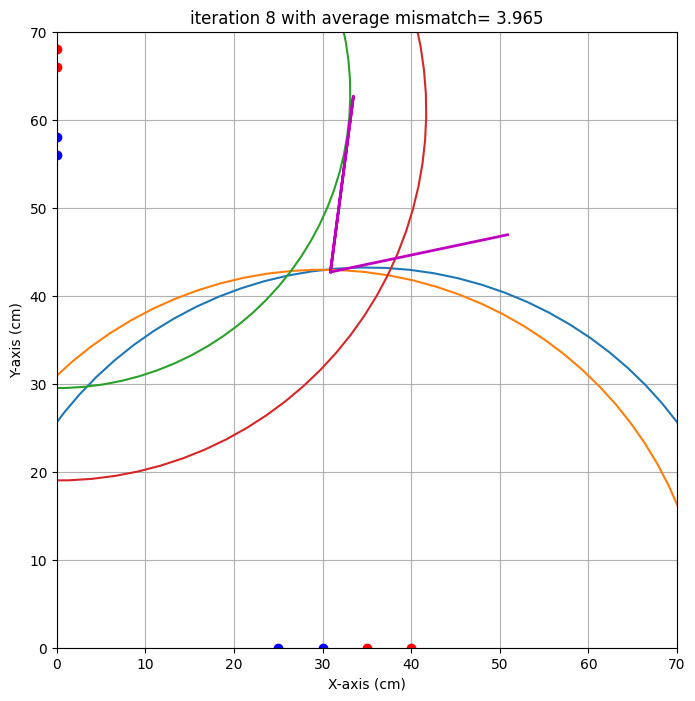

end iteration 8 with average mismatch= 3.965


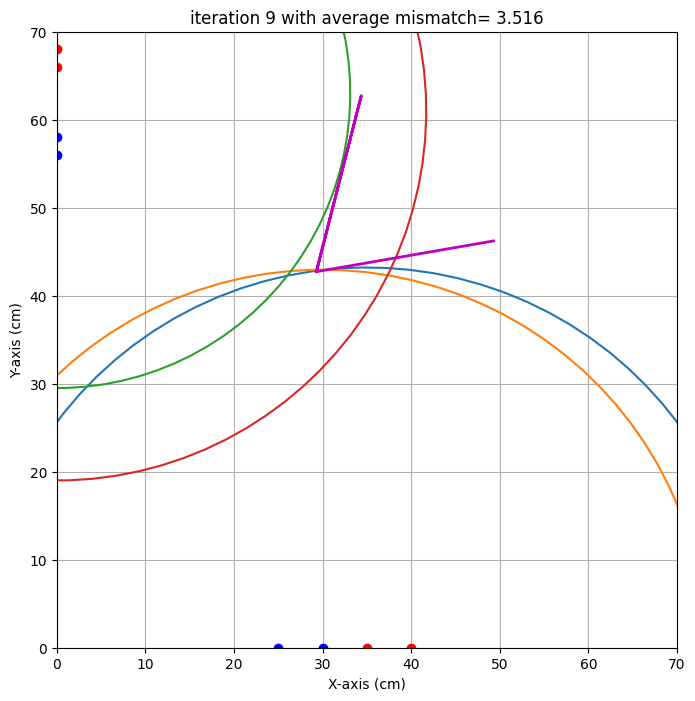

end iteration 9 with average mismatch= 3.516


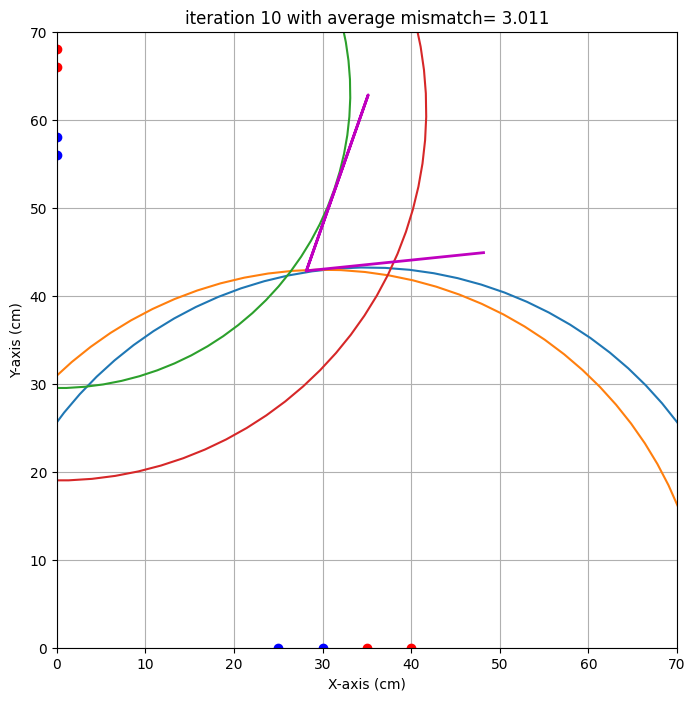

end iteration 10 with average mismatch= 3.011
end iteration 11 with average mismatch= 3.011
end iteration 12 with average mismatch= 3.011
end iteration 13 with average mismatch= 3.011
end iteration 14 with average mismatch= 3.011
end iteration 15 with average mismatch= 3.011
end iteration 16 with average mismatch= 2.947
end iteration 17 with average mismatch= 2.947
end iteration 18 with average mismatch= 2.947
end iteration 19 with average mismatch= 2.947
end iteration 20 with average mismatch= 2.896
end iteration 21 with average mismatch= 2.896
end iteration 22 with average mismatch= 2.896
end iteration 23 with average mismatch= 2.896
end iteration 24 with average mismatch= 2.896
end iteration 25 with average mismatch= 2.896
end iteration 26 with average mismatch= 2.896
end iteration 27 with average mismatch= 2.845
end iteration 28 with average mismatch= 2.845
end iteration 29 with average mismatch= 2.845
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

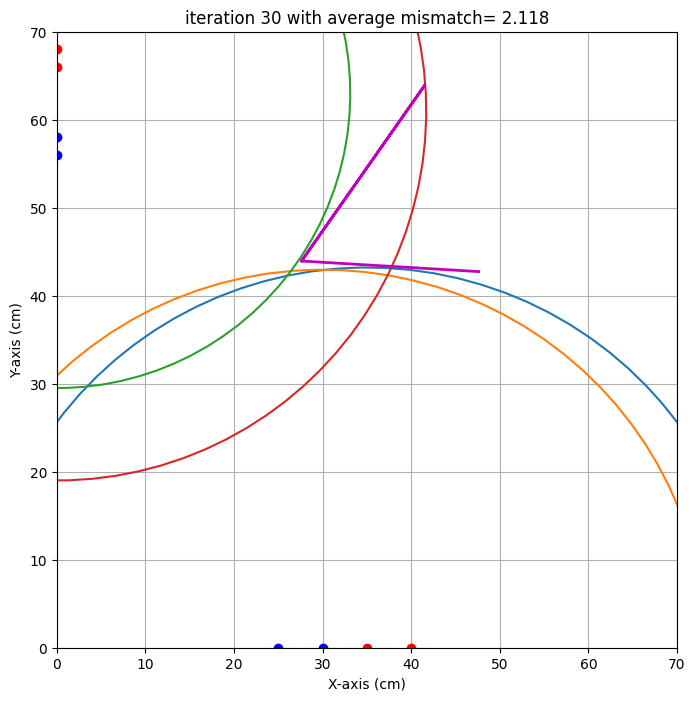

end iteration 30 with average mismatch= 2.118
###############################################################################
end of iteration  30
Best alpha=  -3.43 with uncertainty=  10.67
Best beta =  34.85 with uncertainty=   3.55
Best x0   =  27.62 with uncertainty=   1.87
Best y0   =  43.94 with uncertainty=   1.47
###############################################################################


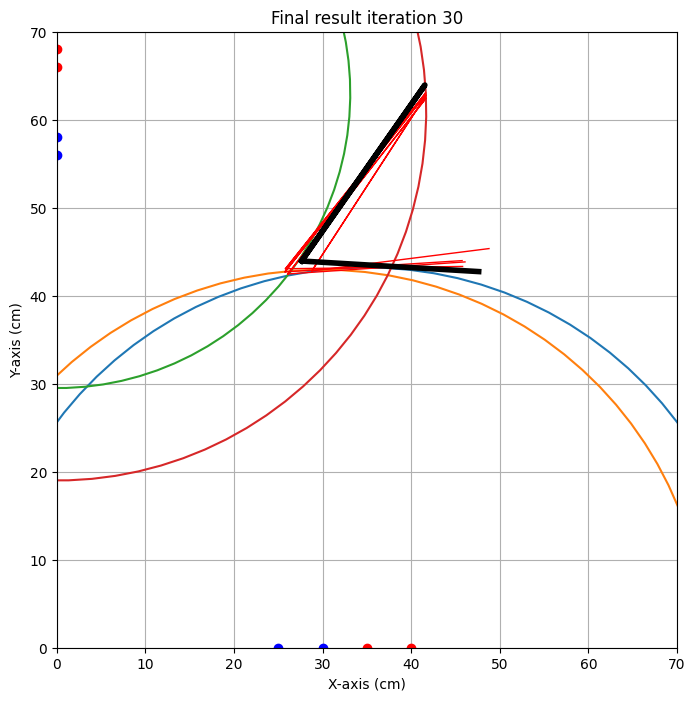

{'alpha': np.float64(-3.433284010944938), 'alpha_eps': np.float64(10.665287950670228), 'beta': np.float64(34.848472021253194), 'beta_eps': np.float64(3.5509574367215464), 'x0': np.float64(27.62051586136891), 'x0_eps': np.float64(1.871058274058928), 'y0': np.float64(43.94289066189894), 'y0_eps': np.float64(1.4683658072644405)}
Laura
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  42   0  33   0  86.0
1  47   0  38   0  84.2
2   0  51   0  68  73.0
3   0  52   0  67  71.0


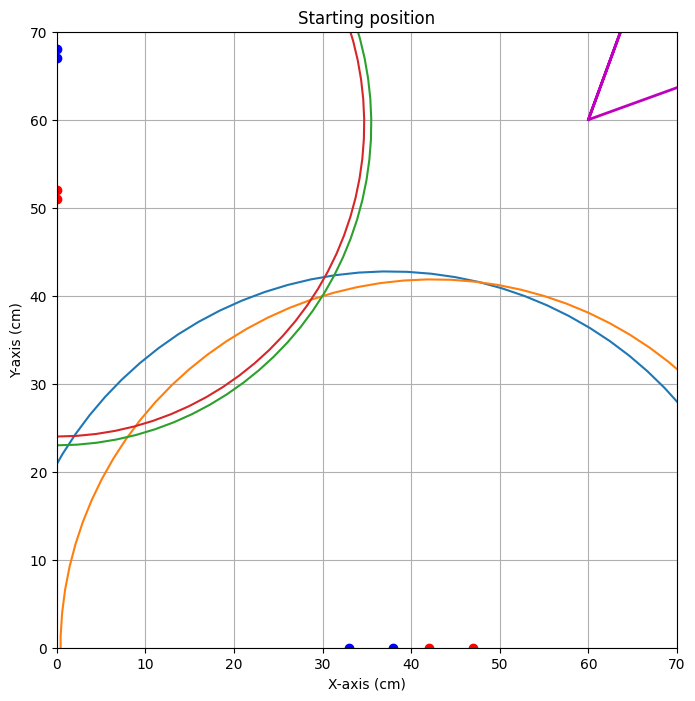


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=50.798


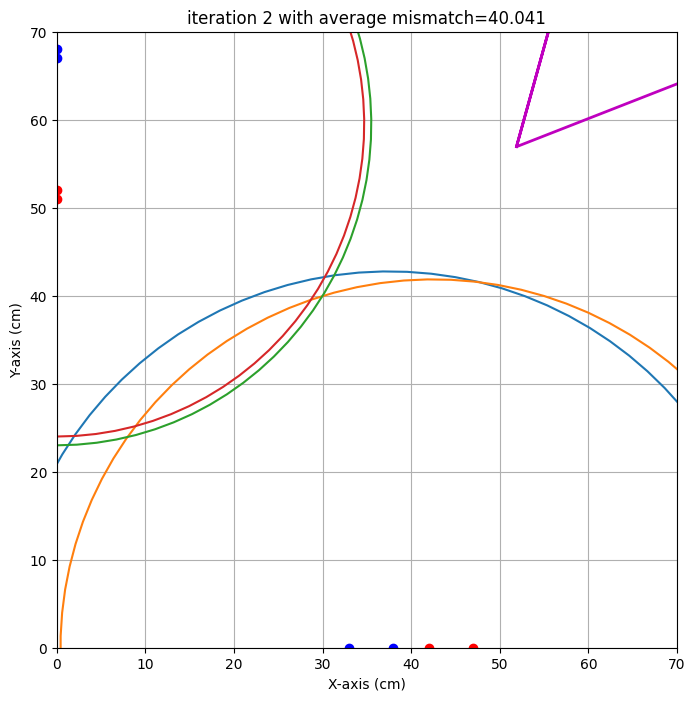

end iteration 2 with average mismatch=40.041


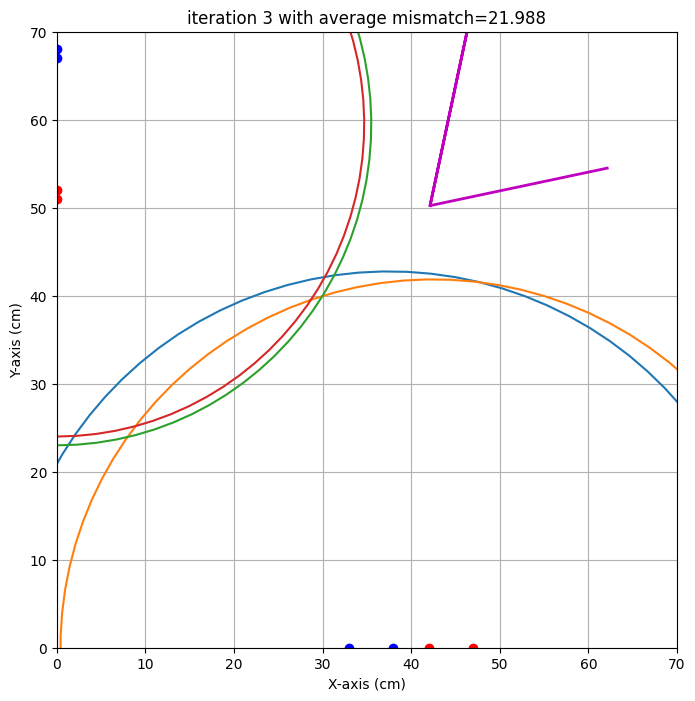

end iteration 3 with average mismatch=21.988


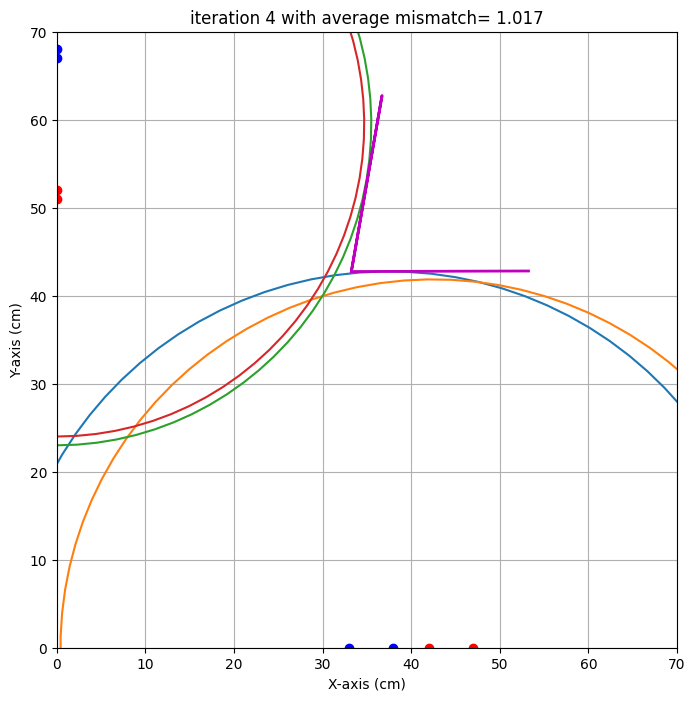

end iteration 4 with average mismatch= 1.017
end iteration 5 with average mismatch= 1.016


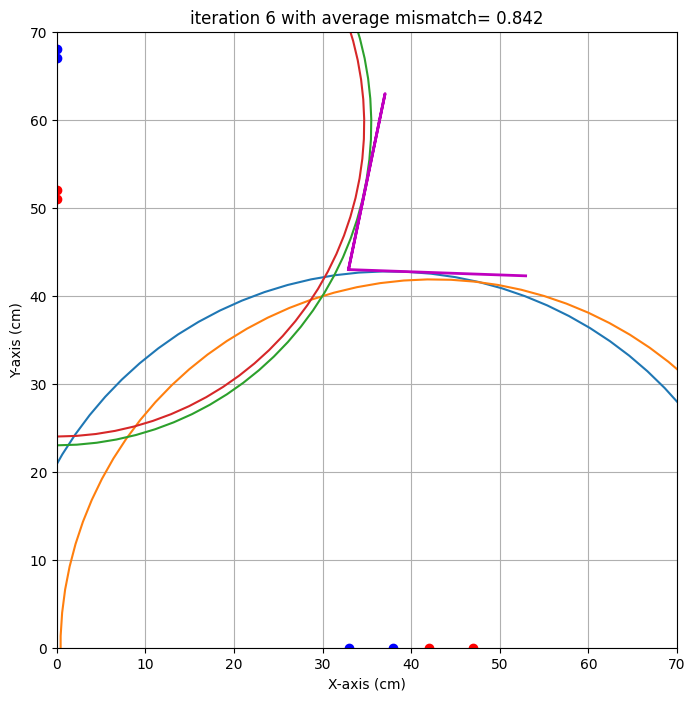

end iteration 6 with average mismatch= 0.842
end iteration 7 with average mismatch= 0.814
end iteration 8 with average mismatch= 0.811
end iteration 9 with average mismatch= 0.811
end iteration 10 with average mismatch= 0.811
end iteration 11 with average mismatch= 0.811
end iteration 12 with average mismatch= 0.811
end iteration 13 with average mismatch= 0.811
end iteration 14 with average mismatch= 0.811
end iteration 15 with average mismatch= 0.811
end iteration 16 with average mismatch= 0.811
end iteration 17 with average mismatch= 0.811
end iteration 18 with average mismatch= 0.811
end iteration 19 with average mismatch= 0.811
end iteration 20 with average mismatch= 0.787
end iteration 21 with average mismatch= 0.755
end iteration 22 with average mismatch= 0.749
end iteration 23 with average mismatch= 0.747
end iteration 24 with average mismatch= 0.684
end iteration 25 with average mismatch= 0.637
end iteration 26 with average mismatch= 0.637
end iteration 27 with average mismatch

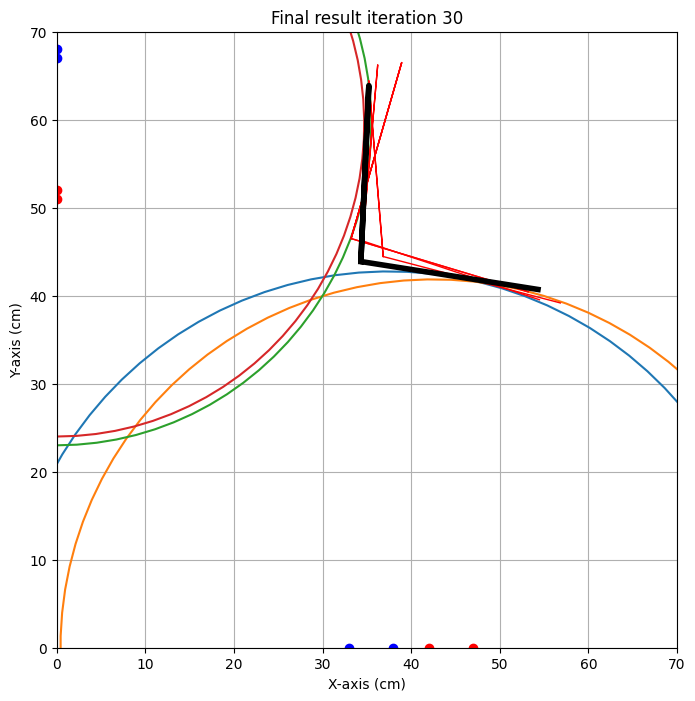

{'alpha': np.float64(-9.01500545910533), 'alpha_eps': np.float64(9.501447820010386), 'beta': np.float64(2.5739841013419866), 'beta_eps': np.float64(13.371186104141422), 'x0': np.float64(34.31799235862174), 'x0_eps': np.float64(2.5232477851735027), 'y0': np.float64(43.88574314030299), 'y0_eps': np.float64(2.6122733144365995)}
Justin
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  20   0  30   0  86.7
1  25   0  35   0  85.0
2   0  52   0  62  66.0
3   0  57   0  67  66.0


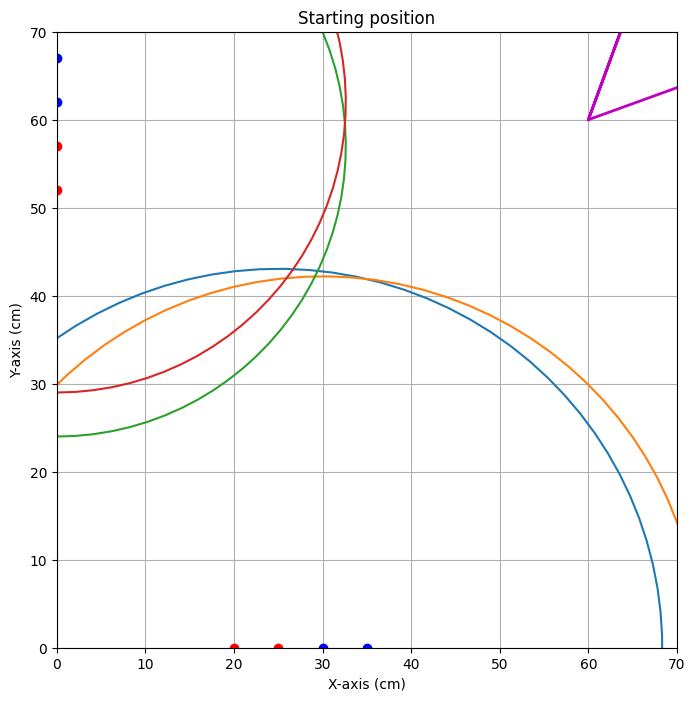


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=57.915


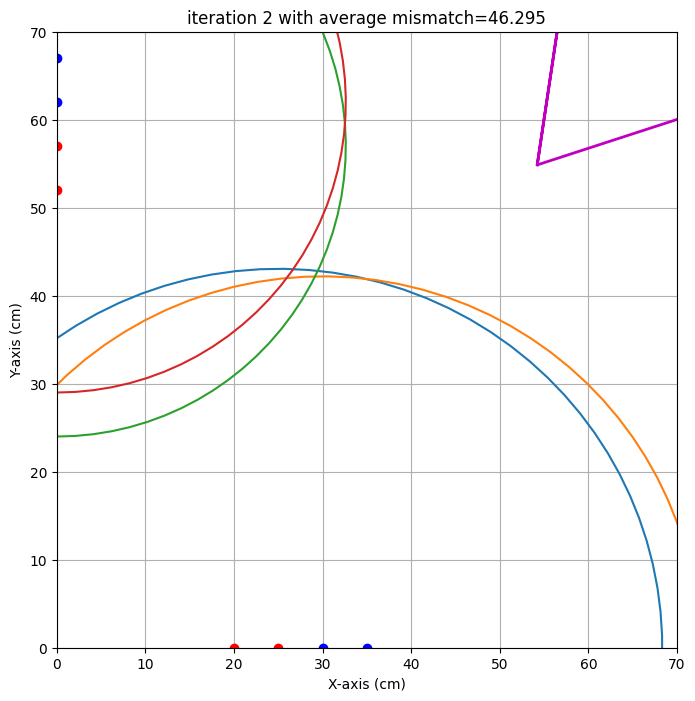

end iteration 2 with average mismatch=46.295


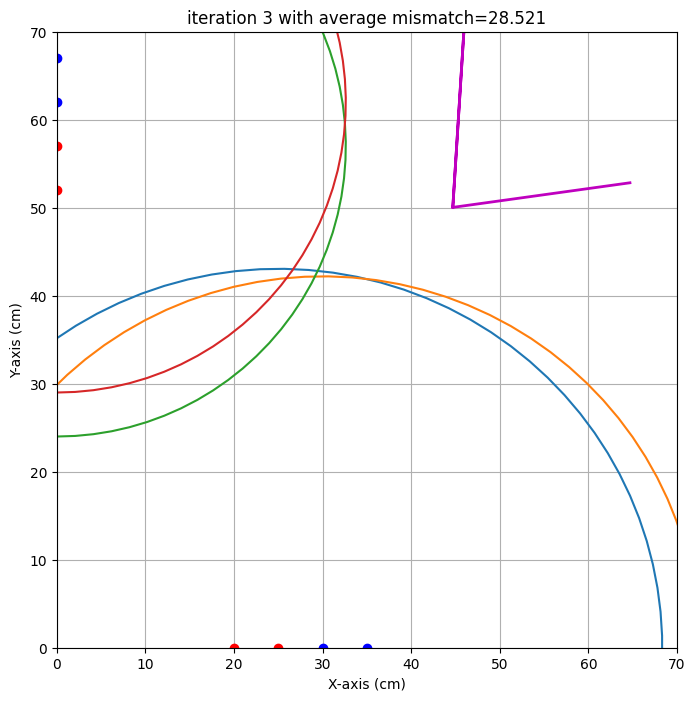

end iteration 3 with average mismatch=28.521


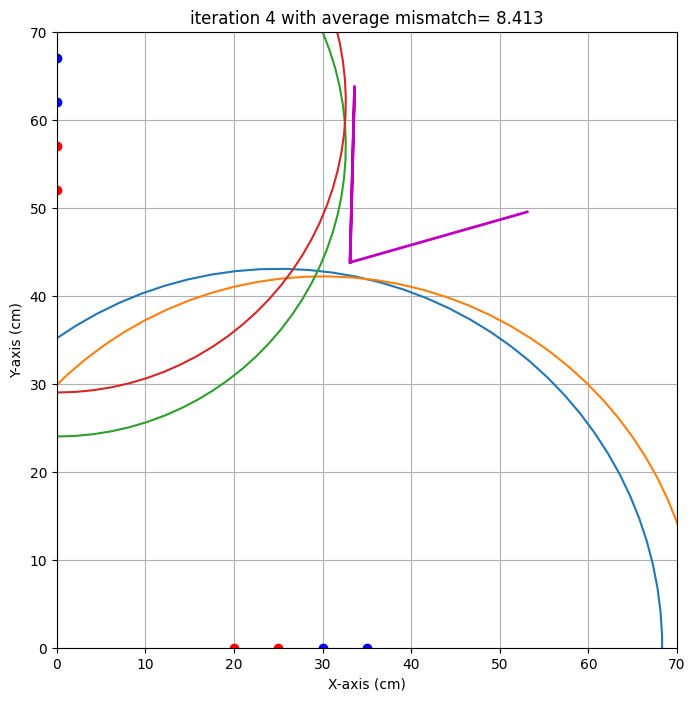

end iteration 4 with average mismatch= 8.413


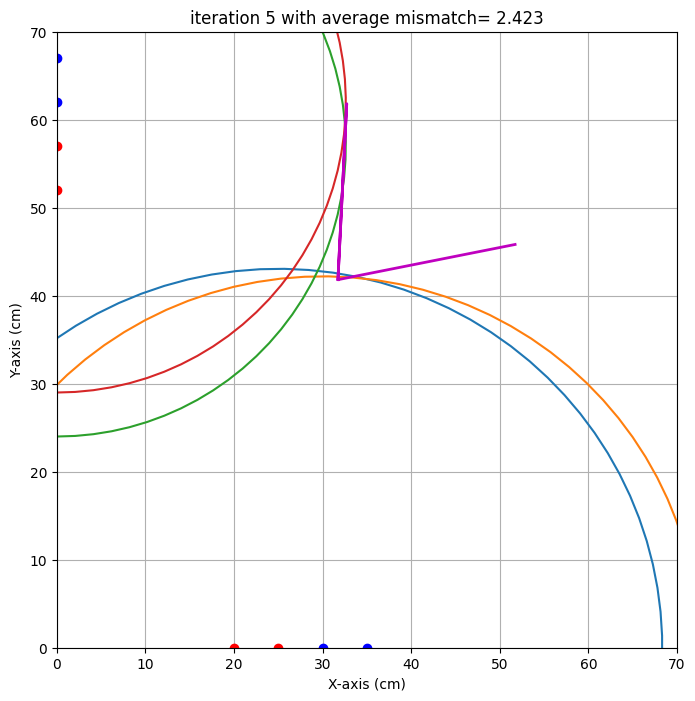

end iteration 5 with average mismatch= 2.423


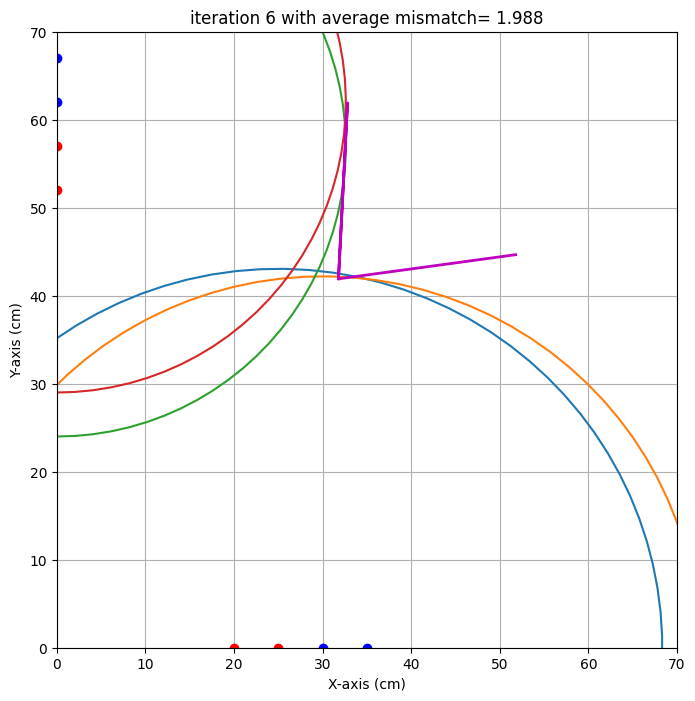

end iteration 6 with average mismatch= 1.988


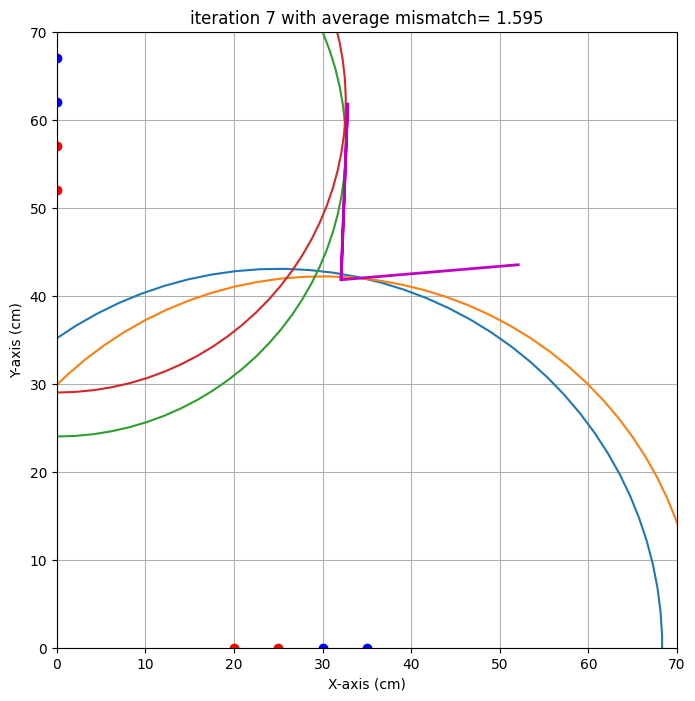

end iteration 7 with average mismatch= 1.595
end iteration 8 with average mismatch= 1.521
end iteration 9 with average mismatch= 1.521
end iteration 10 with average mismatch= 1.399


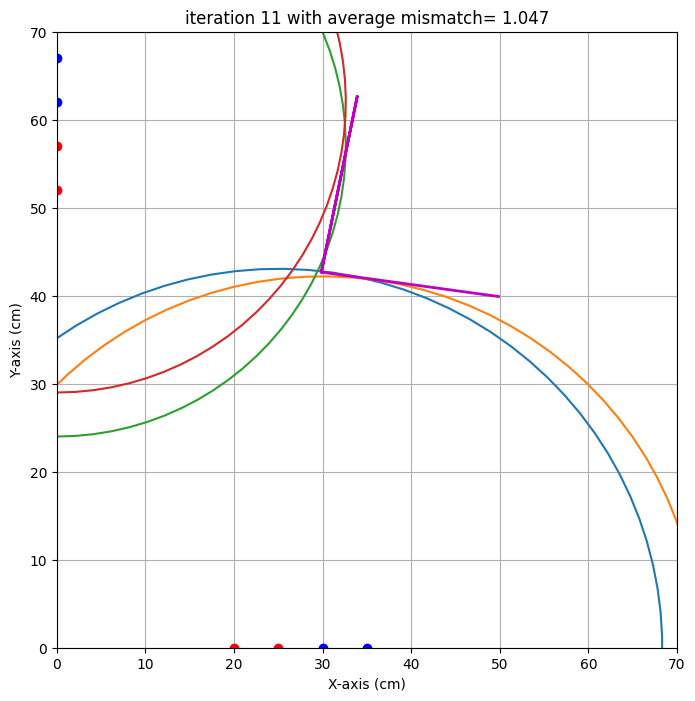

end iteration 11 with average mismatch= 1.047
end iteration 12 with average mismatch= 1.007
end iteration 13 with average mismatch= 0.957


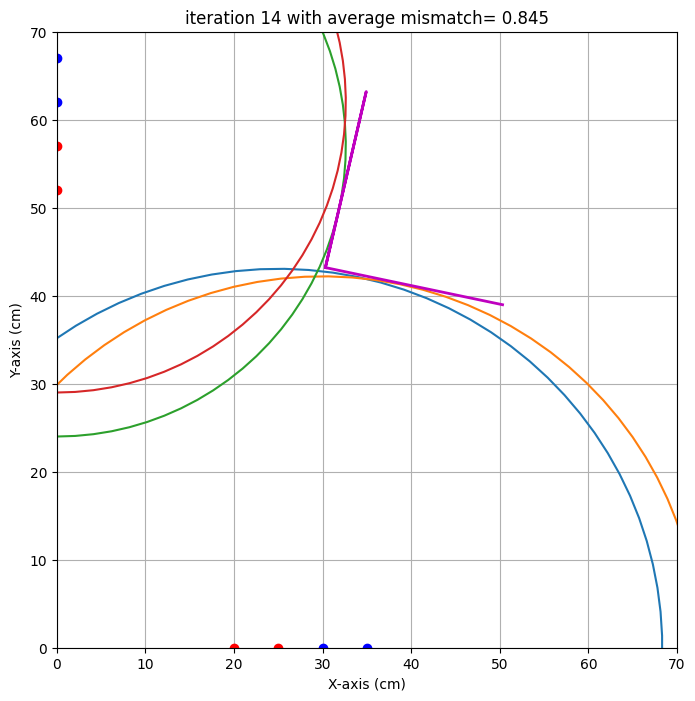

end iteration 14 with average mismatch= 0.845


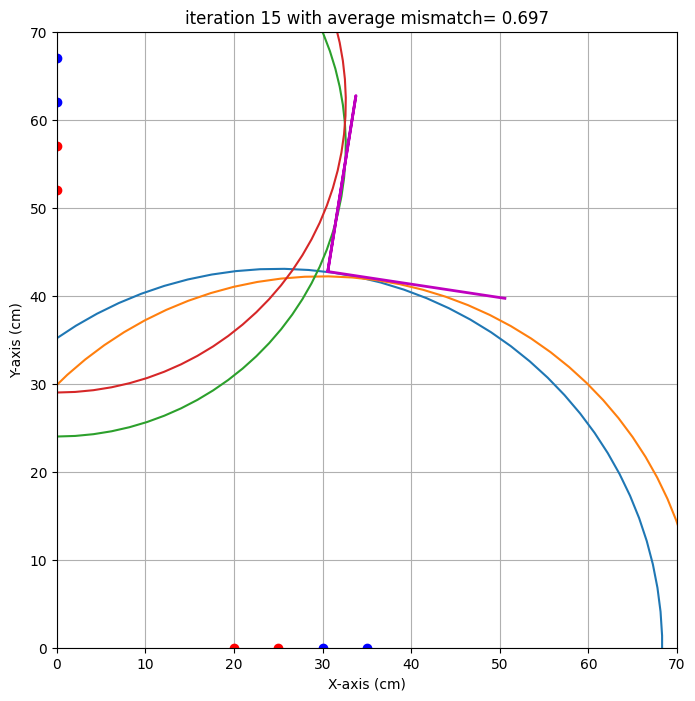

end iteration 15 with average mismatch= 0.697


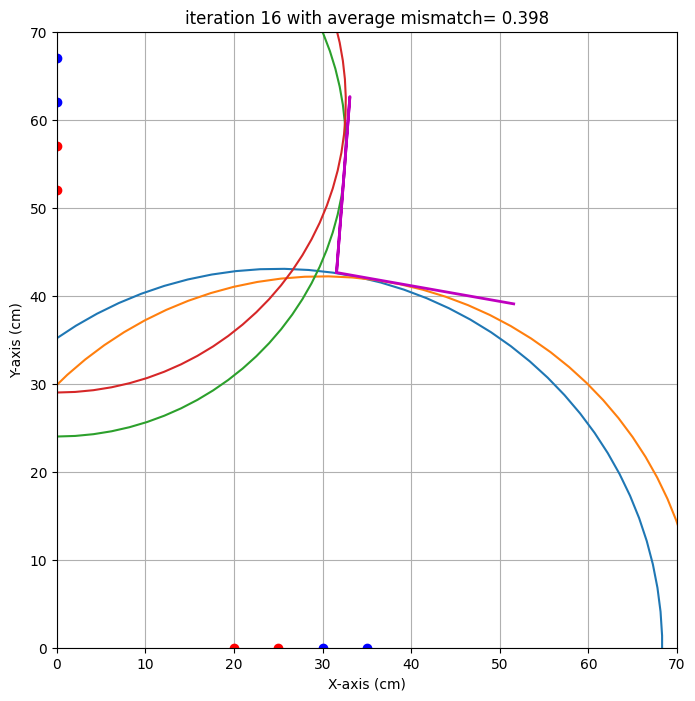

end iteration 16 with average mismatch= 0.398


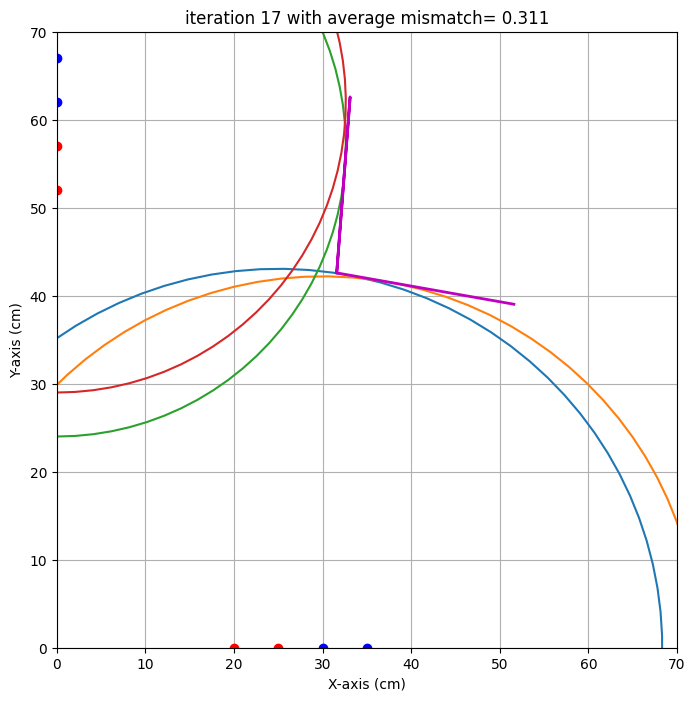

end iteration 17 with average mismatch= 0.311
end iteration 18 with average mismatch= 0.310
end iteration 19 with average mismatch= 0.310
end iteration 20 with average mismatch= 0.310
end iteration 21 with average mismatch= 0.310
end iteration 22 with average mismatch= 0.310
end iteration 23 with average mismatch= 0.305


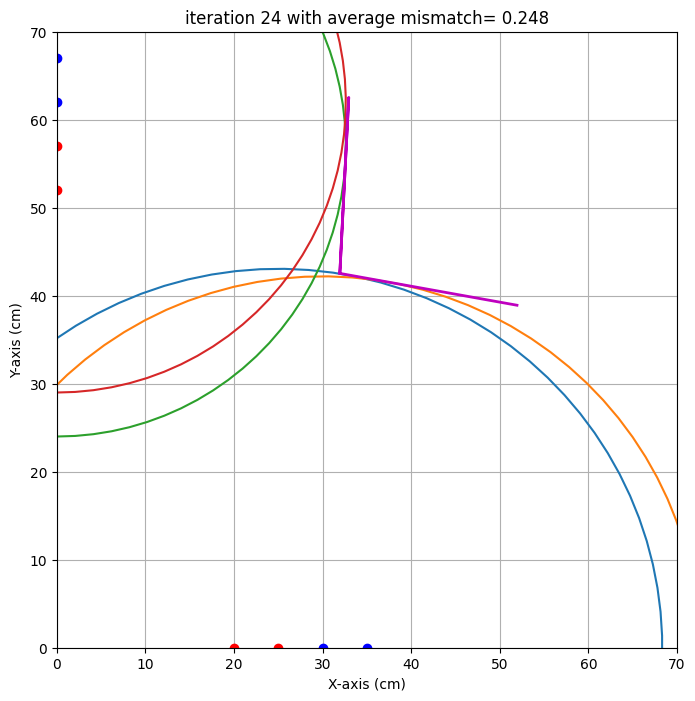

end iteration 24 with average mismatch= 0.248
end iteration 25 with average mismatch= 0.245
end iteration 26 with average mismatch= 0.244
end iteration 27 with average mismatch= 0.244
end iteration 28 with average mismatch= 0.244
end iteration 29 with average mismatch= 0.244
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.244
###############################################################################
end of iteration  30
Best alpha= -10.25 with uncertainty=   2.02
Best beta =   2.87 with uncertainty=   3.32
Best x0   =  31.94 with uncertainty=   0.81
Best y0   =  42.53 with uncertainty=   0.03
###############################################################################


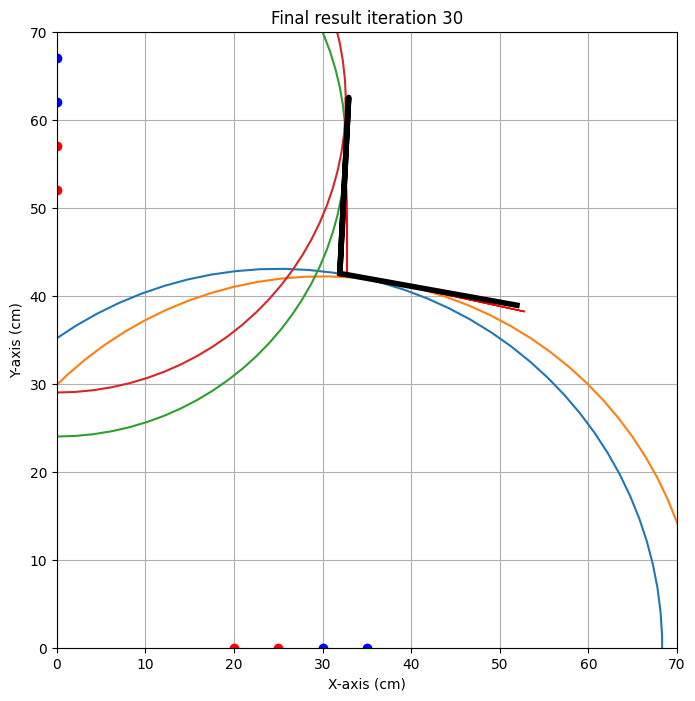

{'alpha': np.float64(-10.253224153160039), 'alpha_eps': np.float64(2.019833921762002), 'beta': np.float64(2.8741865228160584), 'beta_eps': np.float64(3.3236748433218364), 'x0': np.float64(31.941119774279684), 'x0_eps': np.float64(0.8131673064118417), 'y0': np.float64(42.534603615919075), 'y0_eps': np.float64(0.025037265138315945)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Tim 
x0 target is : 29.0. Gevonden waarde: 27.6 cm met een standaardafwijking van 1.9 cm 
y0 target is : 43.0. Gevonden waarde: 43.9 cm met een standaardafwijking van 1.5 cm 
alpha target is : 0.0. Gevonden waarde: -3.4 graden met een standaardafwijking van 10.7 graad 
beta target is : 29.0. Gevonden waarde: 34.8 graden met een standaardafwijking van 3.6 graad 

Laura 
x0 target is : 29.0. Gevonden waarde: 34.3 cm met een standaardafwijking van 2.5 cm 
y0 target is : 43.0. Gevonden waarde: 43.9 cm met een standaardafwijking van 2.6 cm 
alpha target is : 0.0. Gevonden waarde: -9.0 graden met een standaardafwijking van 9.5 graad 
beta target is : 29.0. Gevonden waarde: 2.6 graden met een standaardafwijking van 13.4 graad 

Justin 
x0 target is : 29.0. Gevonden waarde: 31.9 cm met een standaardafwijking van 0.8 cm 
y0 target is : 43.0. Gevonden waarde: 42.5 cm met een standaardafwijking van 0.0 cm 
alpha target is : 0.0. Gevonden waarde: -10.3 graden met een standaardafwijking van 2.0 gra

## Opdracht 8: Iteratie1 15:00.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Iteratie 1: ![Alt](algoritmefinal.jpg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  35   0  45   0  119.0
1  40   0  50   0  118.0
2   0  59   0  69   80.0
3   0  64   0  74   80.0
4   0  69   0  79   81.0
5  45   0  55   0  117.0


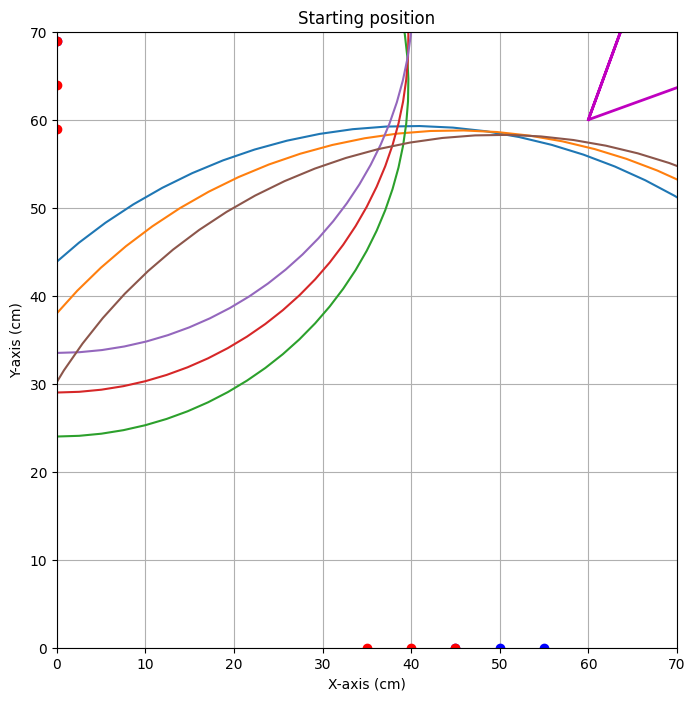


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=28.664


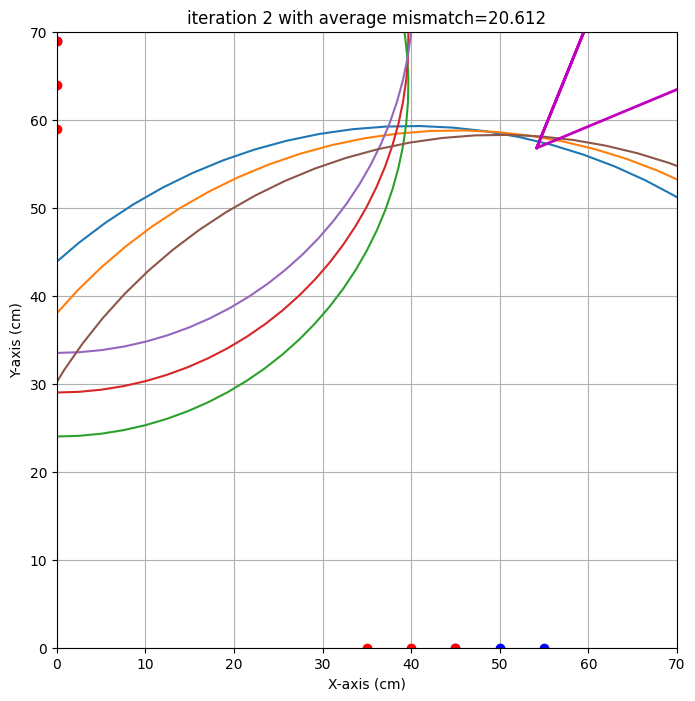

end iteration 2 with average mismatch=20.612


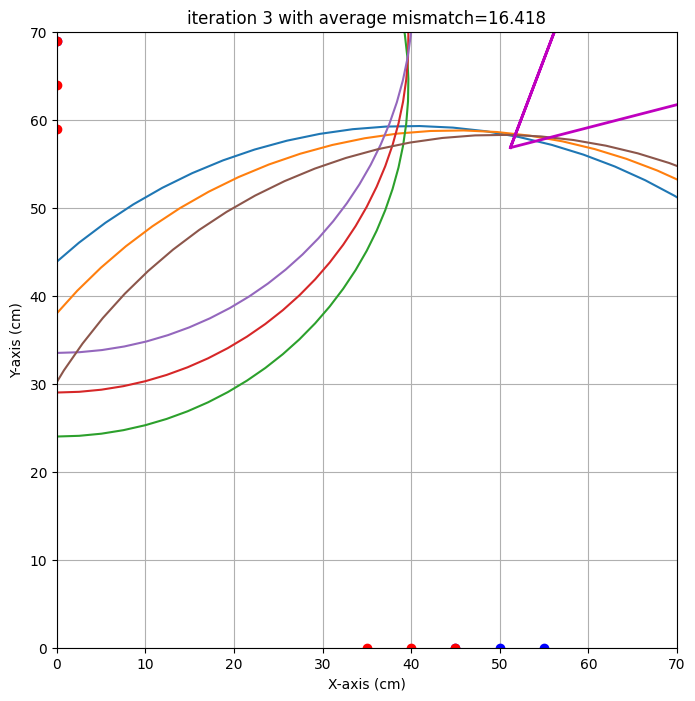

end iteration 3 with average mismatch=16.418


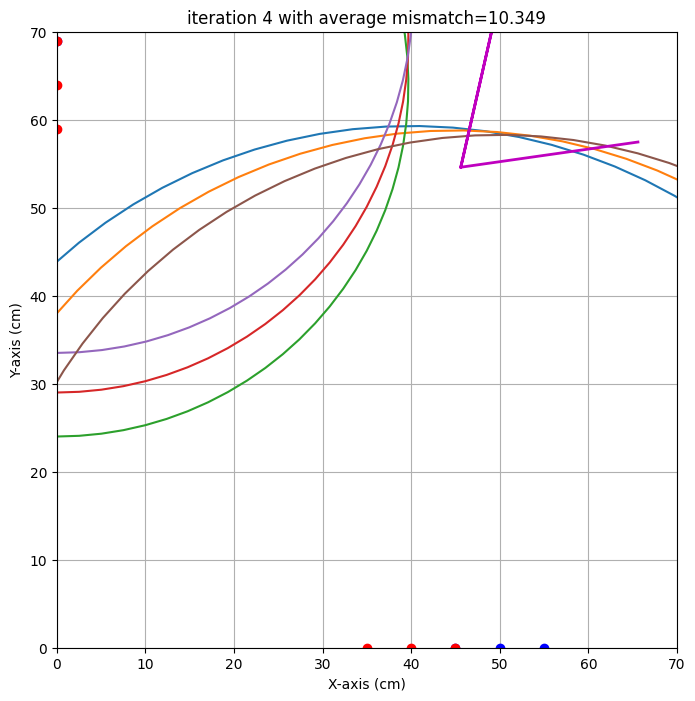

end iteration 4 with average mismatch=10.349


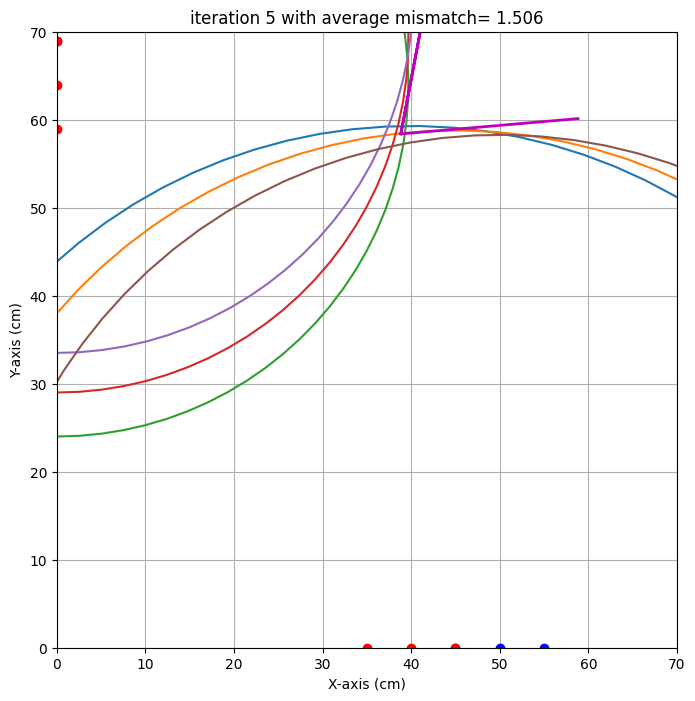

end iteration 5 with average mismatch= 1.506


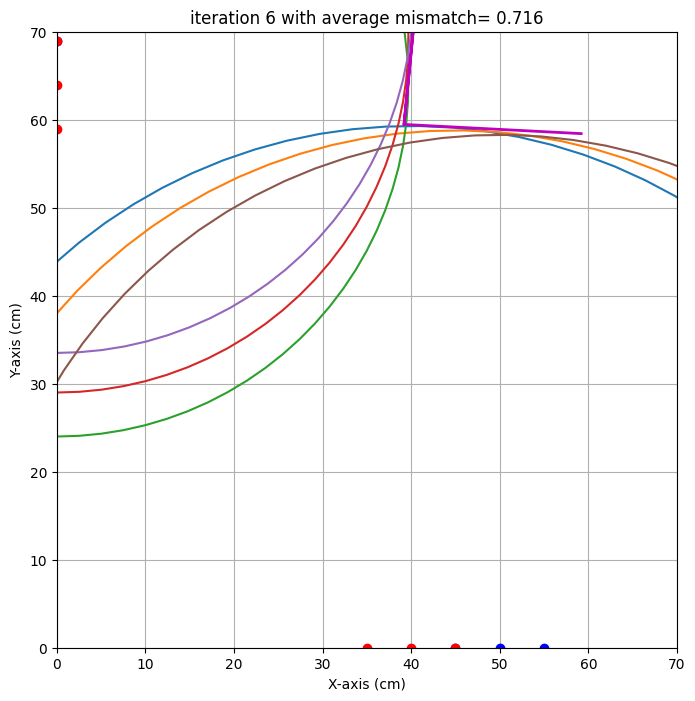

end iteration 6 with average mismatch= 0.716


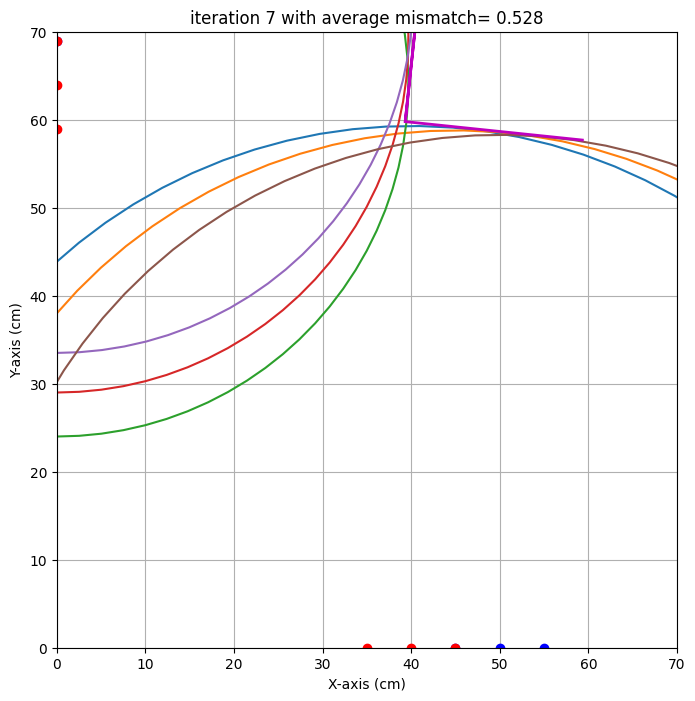

end iteration 7 with average mismatch= 0.528


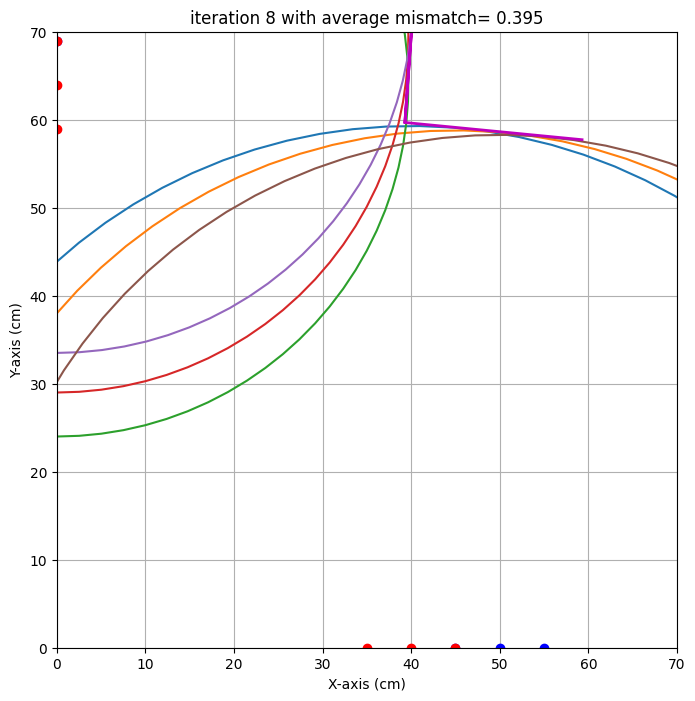

end iteration 8 with average mismatch= 0.395
end iteration 9 with average mismatch= 0.356
end iteration 10 with average mismatch= 0.356
end iteration 11 with average mismatch= 0.356
end iteration 12 with average mismatch= 0.356
end iteration 13 with average mismatch= 0.356
end iteration 14 with average mismatch= 0.356
end iteration 15 with average mismatch= 0.329
end iteration 16 with average mismatch= 0.328
end iteration 17 with average mismatch= 0.327
end iteration 18 with average mismatch= 0.327
end iteration 19 with average mismatch= 0.314


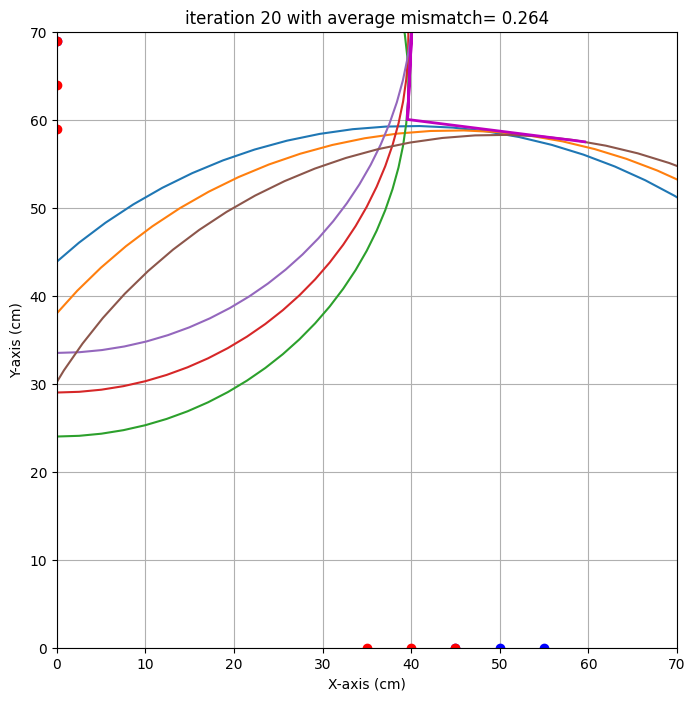

end iteration 20 with average mismatch= 0.264
end iteration 21 with average mismatch= 0.255
end iteration 22 with average mismatch= 0.254
end iteration 23 with average mismatch= 0.254
end iteration 24 with average mismatch= 0.254
end iteration 25 with average mismatch= 0.254
end iteration 26 with average mismatch= 0.254
end iteration 27 with average mismatch= 0.254
end iteration 28 with average mismatch= 0.254
end iteration 29 with average mismatch= 0.254
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.254
###############################################################################
end of iteration  30
Best alpha=  -7.24 with uncertainty=   6.65
Best beta =   2.68 with uncertainty=   2.97
Best x0   =  39.58 with uncertainty=   0.30
Best y0   =  60.03 with uncertainty=   1.16
###############################################################################


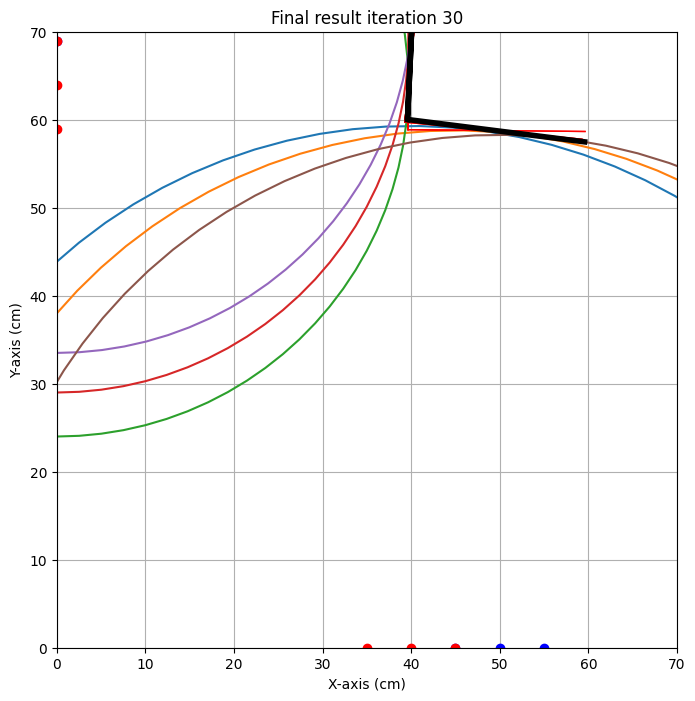

{'alpha': np.float64(-7.237409629687304), 'alpha_eps': np.float64(6.65283302300982), 'beta': np.float64(2.680089745915293), 'beta_eps': np.float64(2.9687162589824236), 'x0': np.float64(39.58028340960113), 'x0_eps': np.float64(0.29720028720448255), 'y0': np.float64(60.025322913383185), 'y0_eps': np.float64(1.1573518121962252)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  35   0  45   0  73.5
1  37   0  47   0  71.8
2  33   0  43   0  72.0
3  39   0  49   0  73.0
4   0  46   0  56  66.5
5   0  44   0  54  67.0
6   0  48   0  58  68.0
7   0  50   0  60  69.2


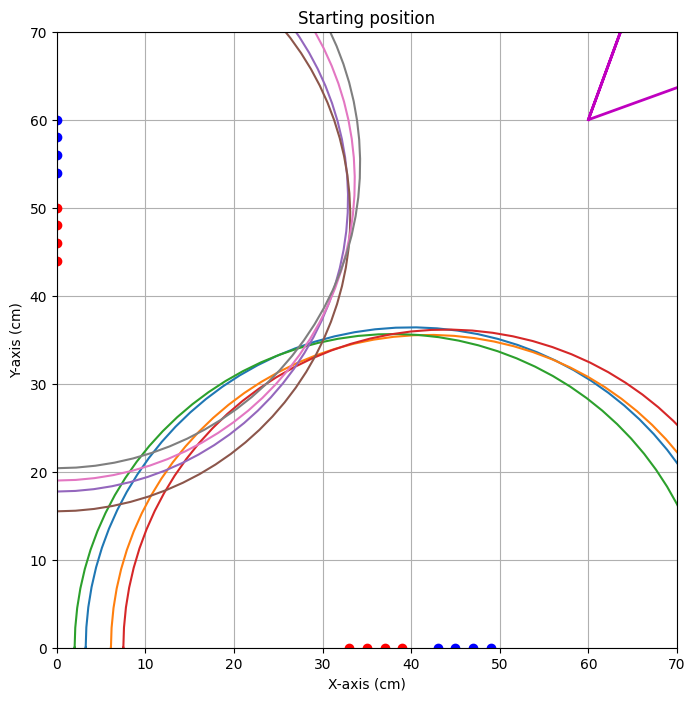


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=59.771


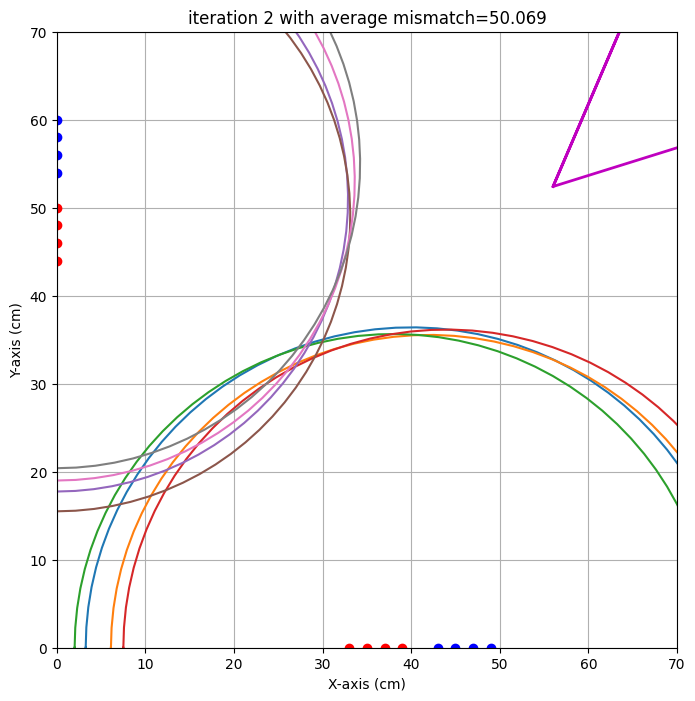

end iteration 2 with average mismatch=50.069


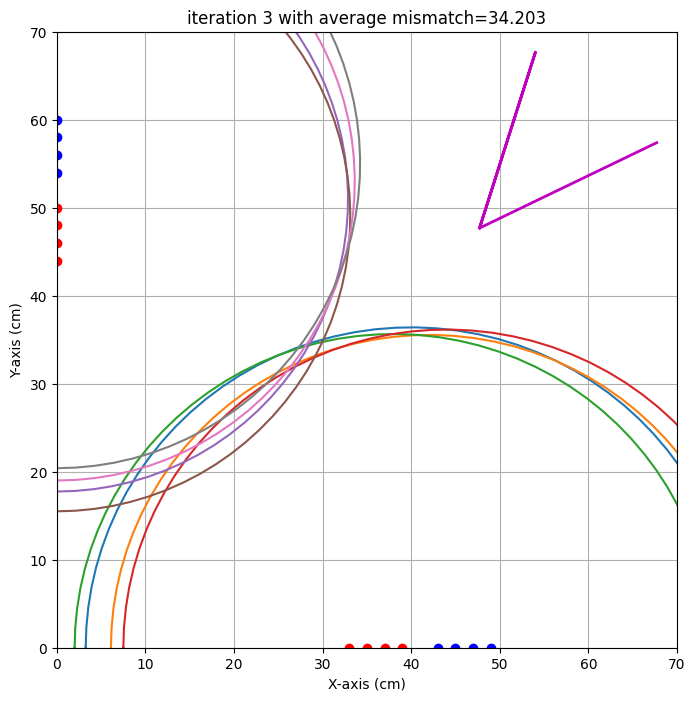

end iteration 3 with average mismatch=34.203


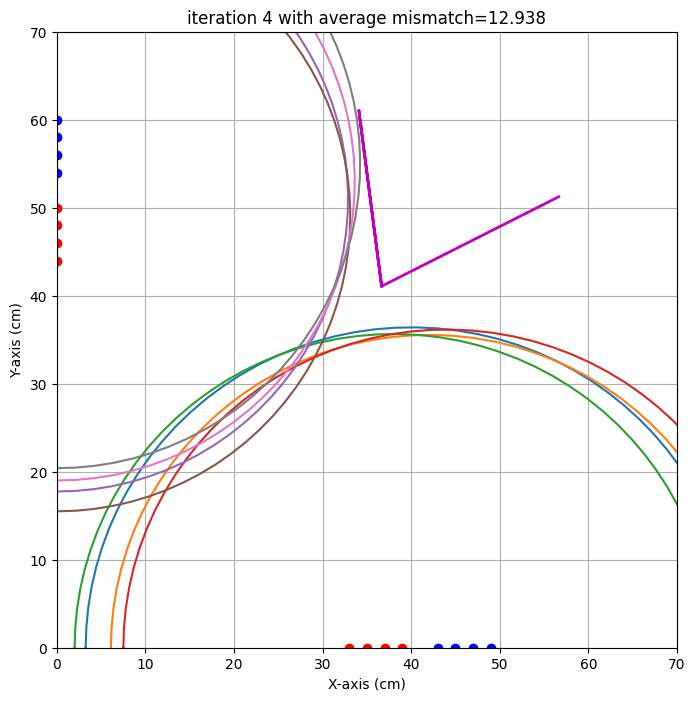

end iteration 4 with average mismatch=12.938


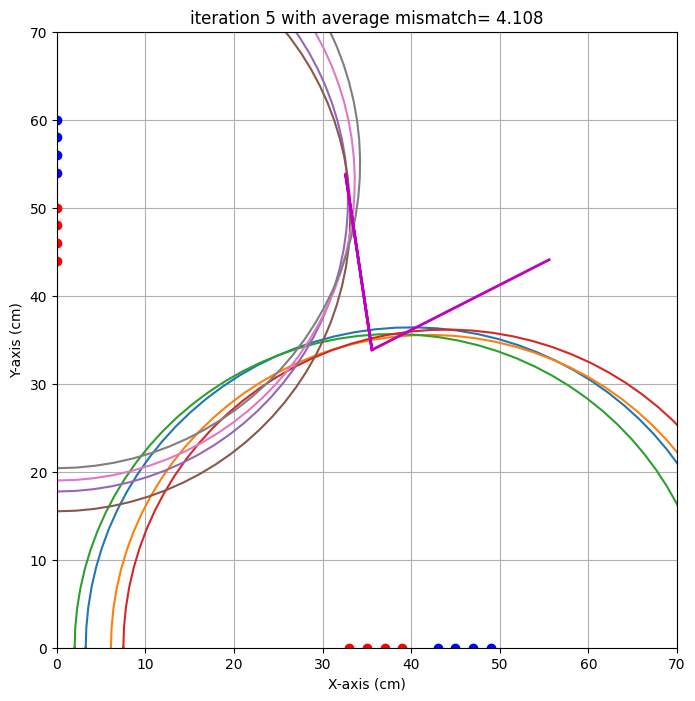

end iteration 5 with average mismatch= 4.108


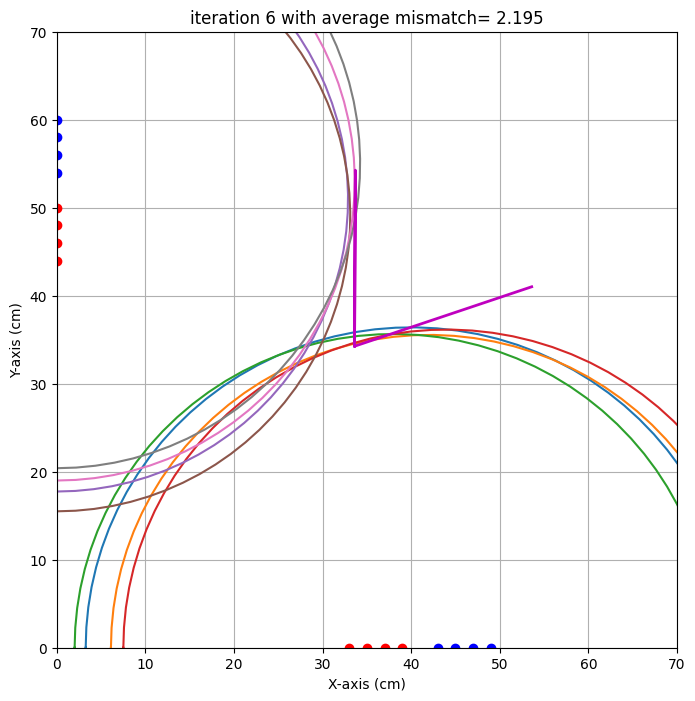

end iteration 6 with average mismatch= 2.195


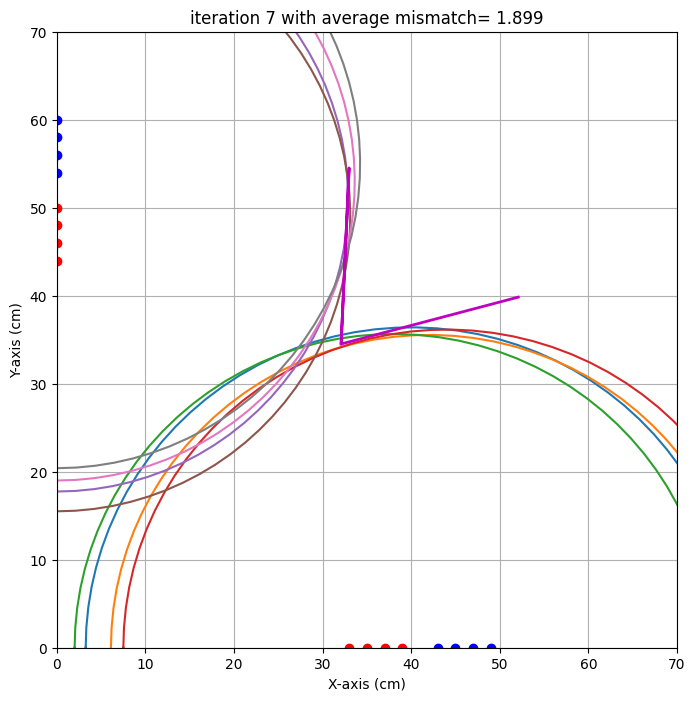

end iteration 7 with average mismatch= 1.899


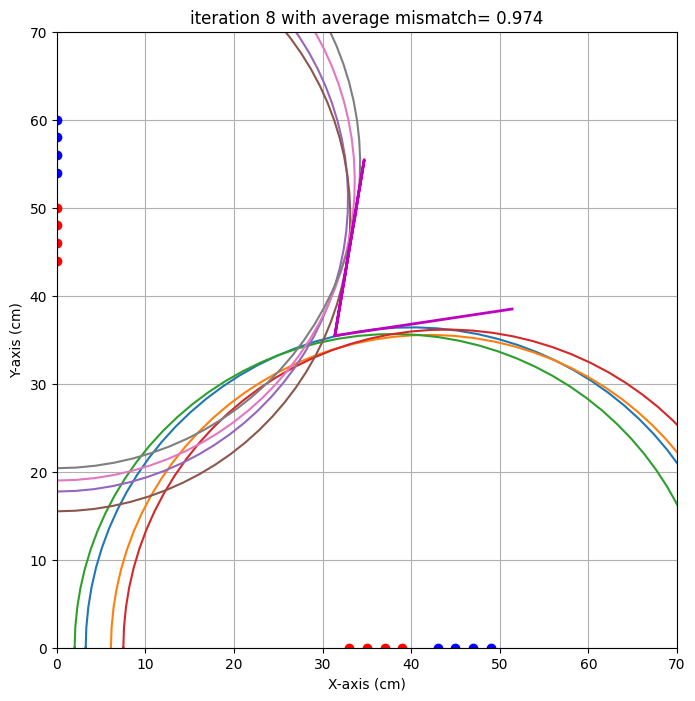

end iteration 8 with average mismatch= 0.974


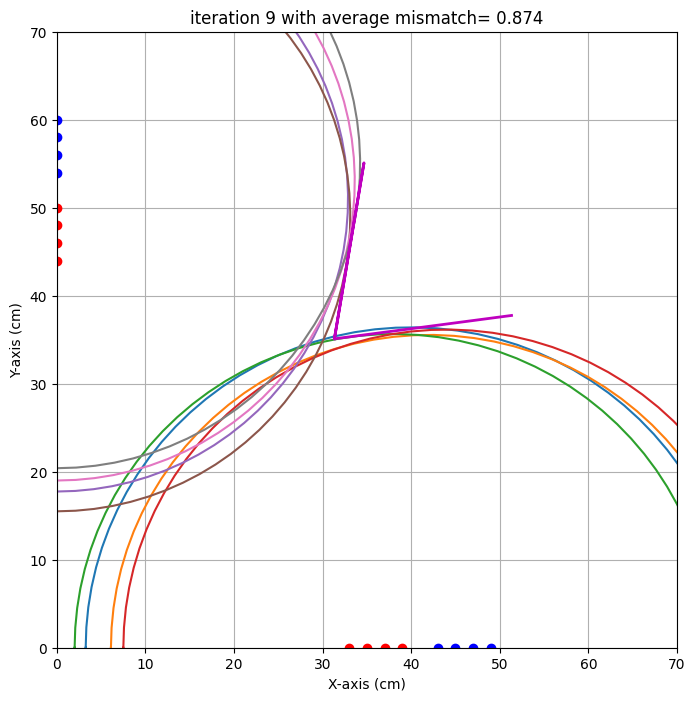

end iteration 9 with average mismatch= 0.874
end iteration 10 with average mismatch= 0.801
end iteration 11 with average mismatch= 0.794
end iteration 12 with average mismatch= 0.792
end iteration 13 with average mismatch= 0.792
end iteration 14 with average mismatch= 0.792
end iteration 15 with average mismatch= 0.792
end iteration 16 with average mismatch= 0.792
end iteration 17 with average mismatch= 0.792
end iteration 18 with average mismatch= 0.792
end iteration 19 with average mismatch= 0.792
end iteration 20 with average mismatch= 0.779
end iteration 21 with average mismatch= 0.762
end iteration 22 with average mismatch= 0.760
end iteration 23 with average mismatch= 0.752
end iteration 24 with average mismatch= 0.751
end iteration 25 with average mismatch= 0.751
end iteration 26 with average mismatch= 0.751
end iteration 27 with average mismatch= 0.751
end iteration 28 with average mismatch= 0.698
end iteration 29 with average mismatch= 0.692
Last iteration, also determine unce

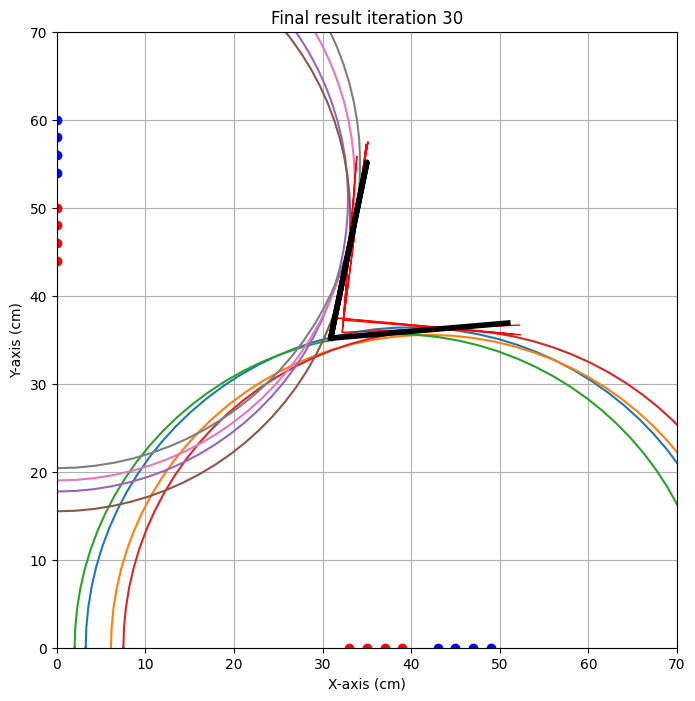

{'alpha': np.float64(4.909337238099868), 'alpha_eps': np.float64(10.159246511993613), 'beta': np.float64(11.555248653996381), 'beta_eps': np.float64(6.855670304763436), 'x0': np.float64(30.912195001235013), 'x0_eps': np.float64(1.440911827483248), 'y0': np.float64(35.17528699995127), 'y0_eps': np.float64(2.2928575614473417)}
locatie 1 
x0 target is : 38.0. Gevonden waarde: 39.6 cm met een standaardafwijking van 0.3 cm 
y0 target is : 57.0. Gevonden waarde: 60.0 cm met een standaardafwijking van 1.2 cm 
alpha target is : 20.0. Gevonden waarde: -7.2 graden met een standaardafwijking van 6.7 graad 
beta target is : 19.0. Gevonden waarde: 2.7 graden met een standaardafwijking van 3.0 graad 

locatie 2 
x0 target is : 34.0. Gevonden waarde: 30.9 cm met een standaardafwijking van 1.4 cm 
y0 target is : 35.0. Gevonden waarde: 35.2 cm met een standaardafwijking van 2.3 cm 
alpha target is : 20.0. Gevonden waarde: 4.9 graden met een standaardafwijking van 10.2 graad 
beta target is : 15.0. Gevo

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 38,
                    'y0': 57,
                    'alpha' : 20,
                    'beta' : 19},
           'locatie 2':{'x0':34,
                    'y0':35,
                    'alpha' :20,
                    'beta' :15 }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [35, 0, 45, 0, 119.0],
    [40, 0, 50, 0, 118.0],
    [0, 59, 0, 69, 80],
    [0, 64, 0, 74, 80],
    [0, 69, 0, 79, 81],
    [45, 0, 55, 0, 117]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [35, 0, 45, 0, 73.5],
    [37, 0, 47, 0, 71.8],
    [33, 0, 43, 0, 72],
    [39, 0, 49, 0, 73],
    [0, 46, 0, 56, 66.5],
    [0, 44, 0, 54, 67.0],
    [0, 48, 0, 58, 68],
    [0, 50, 0, 60, 69.2],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  35   0  45   0  64.5
1  40   0  50   0  65.9
2  45   0  55   0  67.6
3  50   0  60   0  71.8
4  55   0  65   0  74.5
5   0  42   0  52  52.6
6   0  47   0  57  53.2
7   0  52   0  62  53.6
8   0  37   0  47  52.2
9   0  32   0  42  50.9


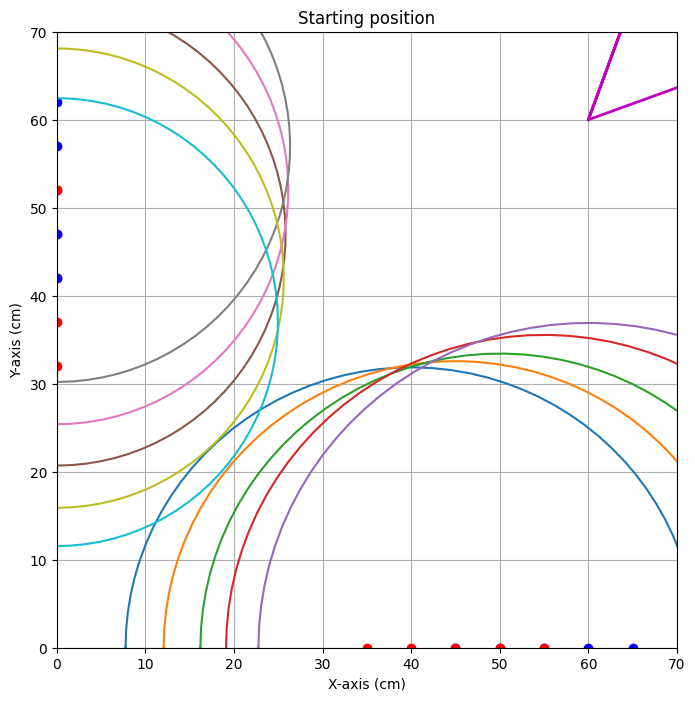


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=69.016


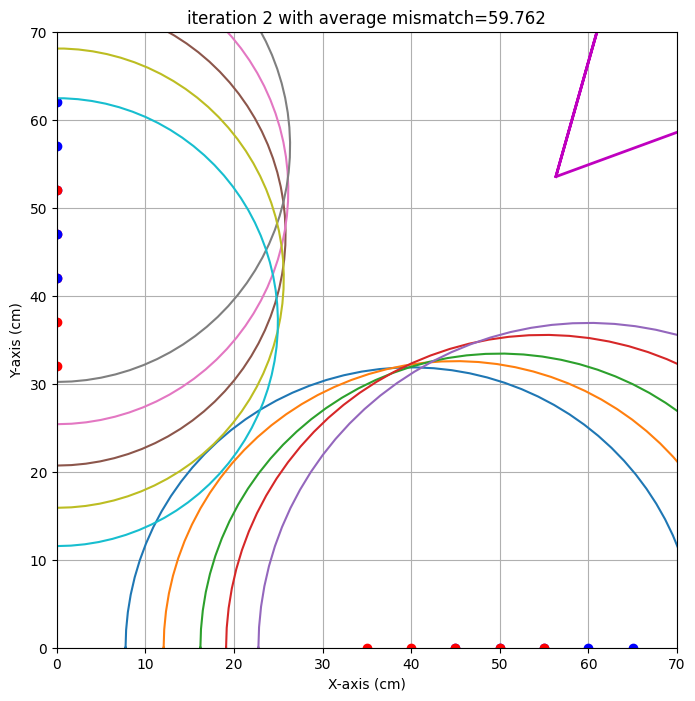

end iteration 2 with average mismatch=59.762


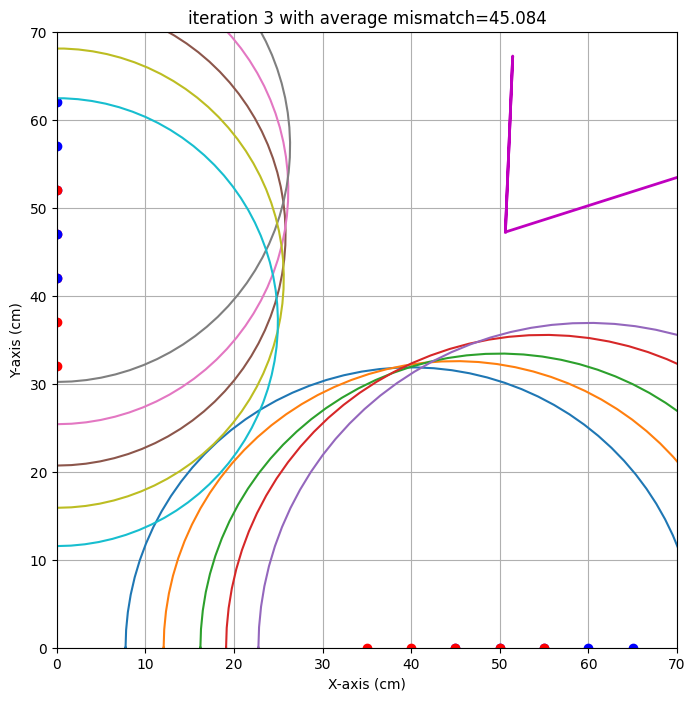

end iteration 3 with average mismatch=45.084


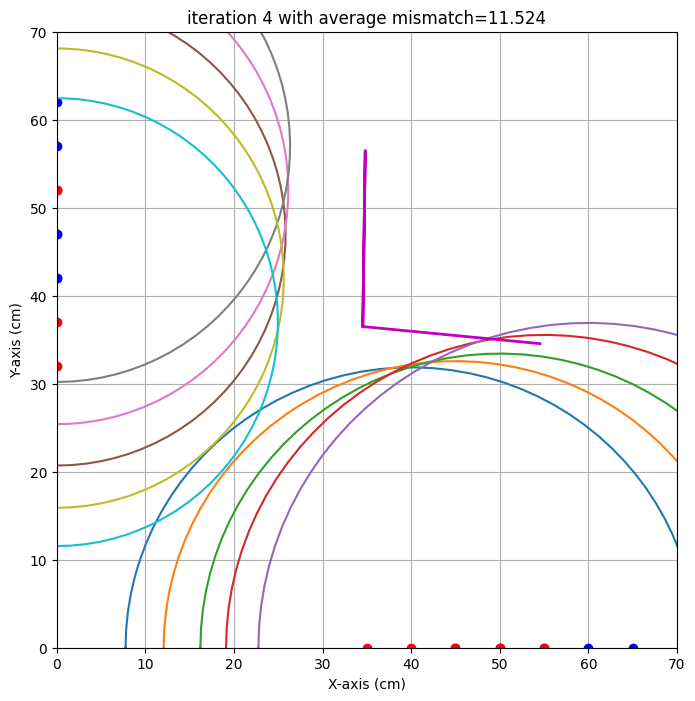

end iteration 4 with average mismatch=11.524


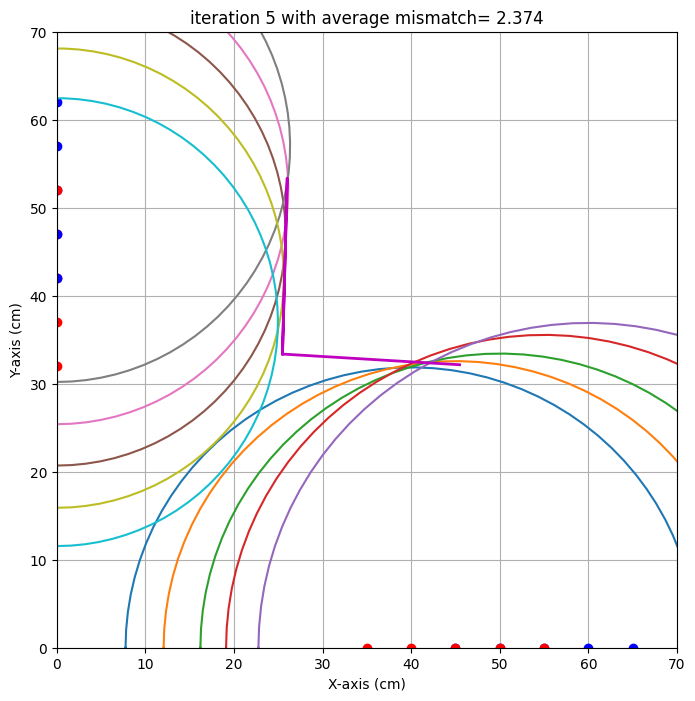

end iteration 5 with average mismatch= 2.374
end iteration 6 with average mismatch= 2.371


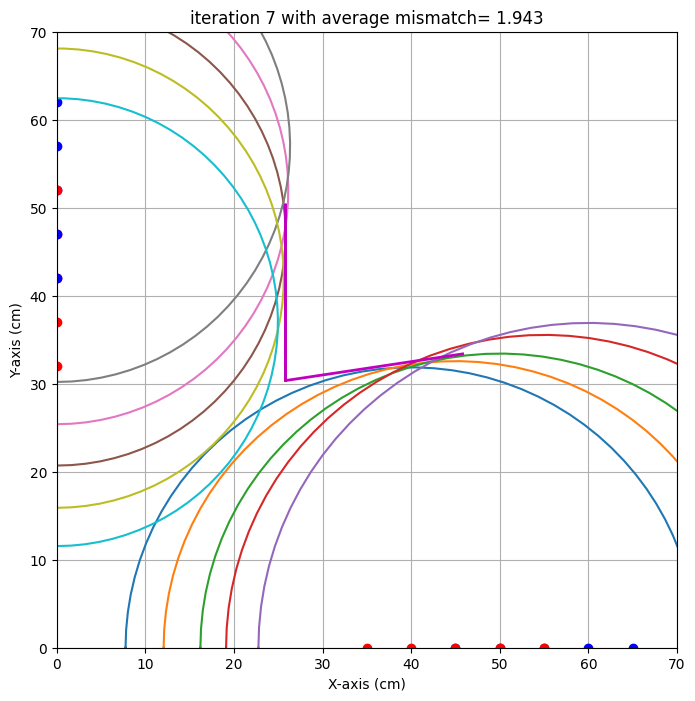

end iteration 7 with average mismatch= 1.943
end iteration 8 with average mismatch= 1.863
end iteration 9 with average mismatch= 1.856
end iteration 10 with average mismatch= 1.854
end iteration 11 with average mismatch= 1.854
end iteration 12 with average mismatch= 1.684
end iteration 13 with average mismatch= 1.682
end iteration 14 with average mismatch= 1.682
end iteration 15 with average mismatch= 1.682
end iteration 16 with average mismatch= 1.682
end iteration 17 with average mismatch= 1.682
end iteration 18 with average mismatch= 1.682
end iteration 19 with average mismatch= 1.682
end iteration 20 with average mismatch= 1.682
end iteration 21 with average mismatch= 1.682
end iteration 22 with average mismatch= 1.682
end iteration 23 with average mismatch= 1.682
end iteration 24 with average mismatch= 1.682
end iteration 25 with average mismatch= 1.682
end iteration 26 with average mismatch= 1.682
end iteration 27 with average mismatch= 1.682
end iteration 28 with average mismatc

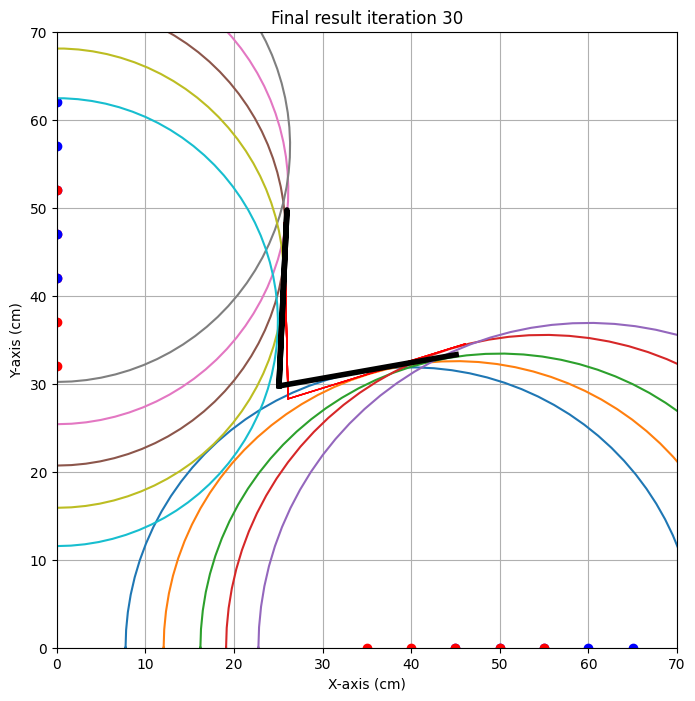

{'alpha': np.float64(10.083462047585165), 'alpha_eps': np.float64(7.253286484865477), 'beta': np.float64(2.5792988325922526), 'beta_eps': np.float64(3.888602395808048), 'x0': np.float64(25.073354785729645), 'x0_eps': np.float64(1.028595181003709), 'y0': np.float64(29.74559781446685), 'y0_eps': np.float64(1.4629922926458967)}
locatie 1 
x0 target is : 27.0. Gevonden waarde: 25.1 cm met een standaardafwijking van 1.0 cm 
y0 target is : 30.0. Gevonden waarde: 29.7 cm met een standaardafwijking van 1.5 cm 
alpha target is : 14.0. Gevonden waarde: 10.1 graden met een standaardafwijking van 7.3 graad 
beta target is : 5.0. Gevonden waarde: 2.6 graden met een standaardafwijking van 3.9 graad 



In [12]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 27,
                    'y0': 30,
                    'alpha' : 14,
                    'beta' : 5}, }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [35, 0, 45, 0, 64.5],
    [40, 0, 50, 0, 65.9],
    [45, 0, 55, 0, 67.6],
    [50, 0, 60, 0, 71.8],
    [55, 0, 65, 0, 74.5],
    [0, 42, 0, 52, 52.6],
    [0, 47, 0, 57, 53.2],
    [0, 52, 0, 62, 53.6],
    [0, 37, 0, 47, 52.2],
    [0, 32, 0, 42, 50.9],
    ])}                   
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
    xs  ys  xr  yr     R
0   25   0  35   0  79.3
1   30   0  40   0  78.6
2   35   0  45   0  80.0
3   40   0  50   0  82.4
4   45   0  55   0  84.8
5   50   0  60   0  87.2
6    0  45   0  55  51.8
7    0  50   0  60  53.6
8    0  55   0  65  56.0
9    0  60   0  70  56.8
10   0  65   0  75  62.2
11   0  40   0  50  52.3


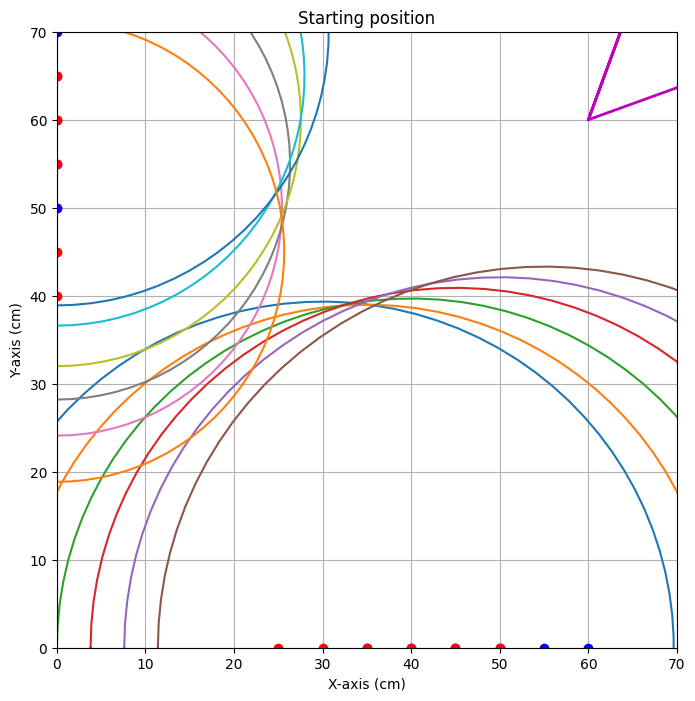


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.837


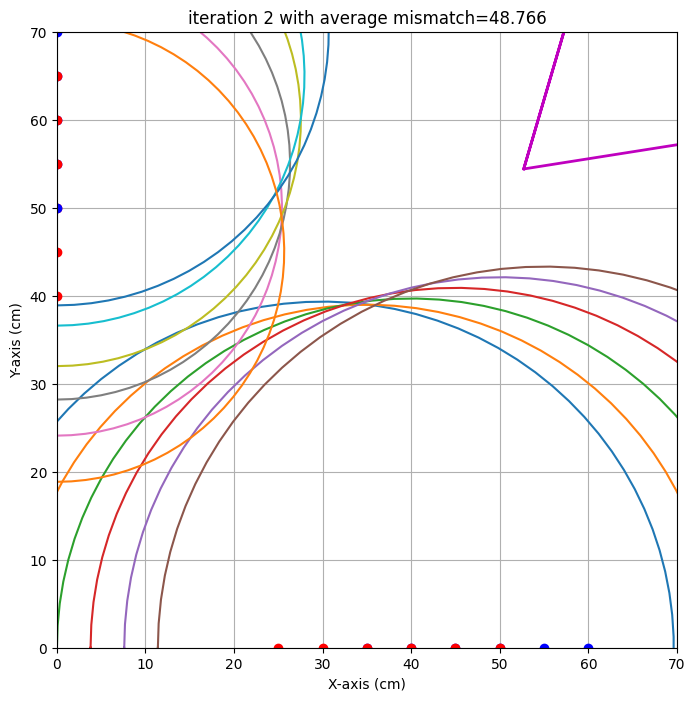

end iteration 2 with average mismatch=48.766


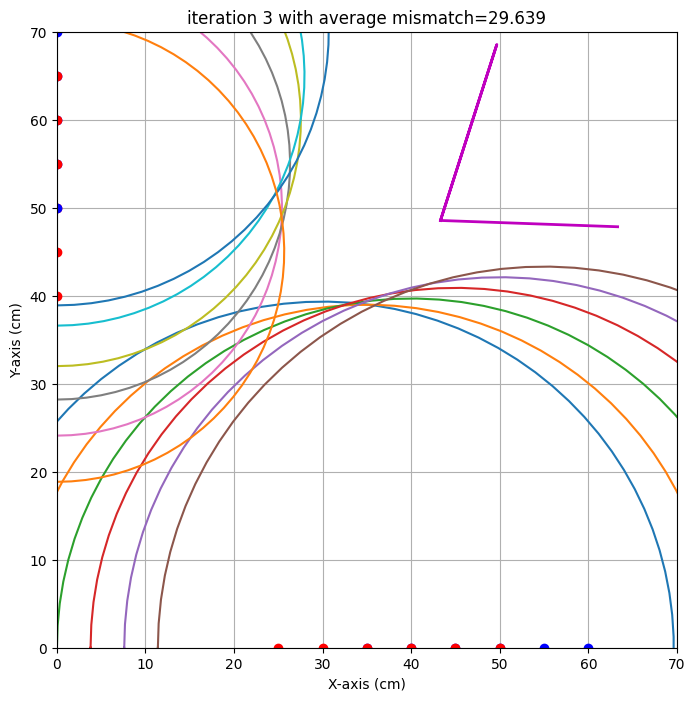

end iteration 3 with average mismatch=29.639


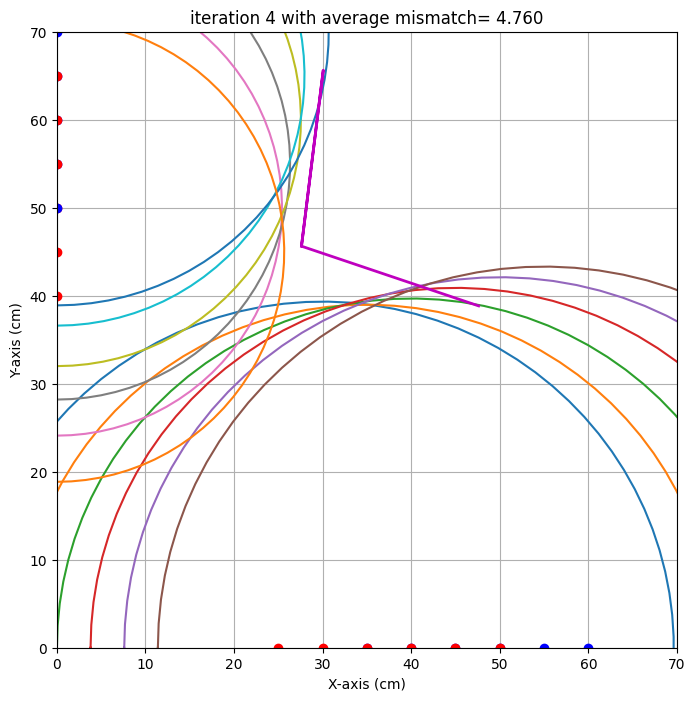

end iteration 4 with average mismatch= 4.760


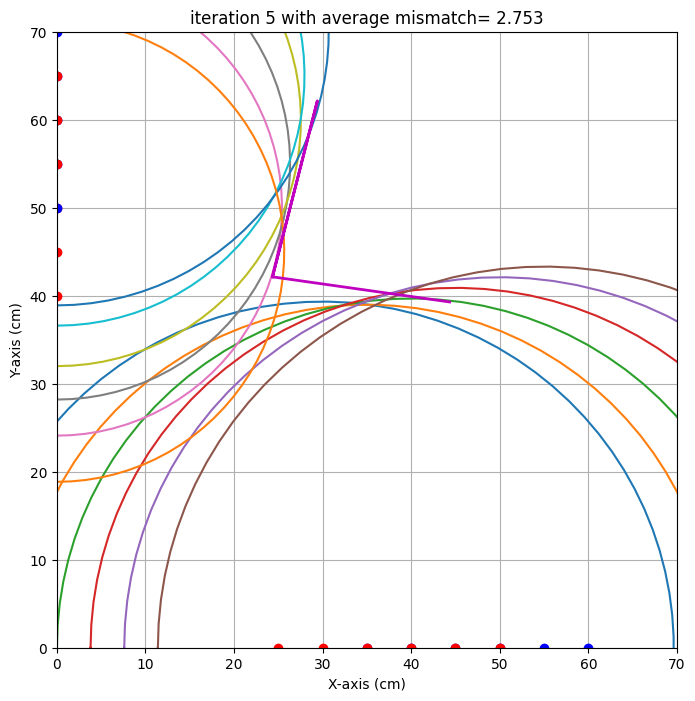

end iteration 5 with average mismatch= 2.753


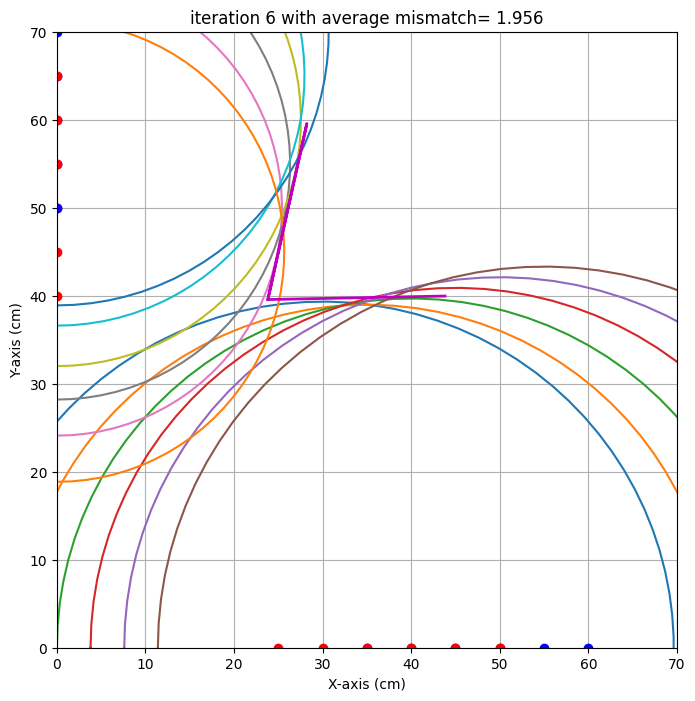

end iteration 6 with average mismatch= 1.956


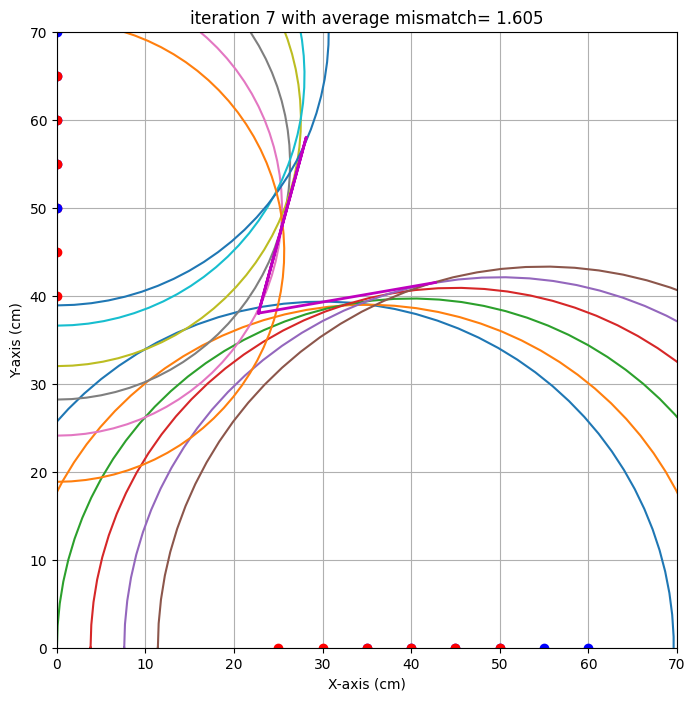

end iteration 7 with average mismatch= 1.605
end iteration 8 with average mismatch= 1.563
end iteration 9 with average mismatch= 1.553
end iteration 10 with average mismatch= 1.535
end iteration 11 with average mismatch= 1.527
end iteration 12 with average mismatch= 1.524
end iteration 13 with average mismatch= 1.523
end iteration 14 with average mismatch= 1.522
end iteration 15 with average mismatch= 1.522
end iteration 16 with average mismatch= 1.522
end iteration 17 with average mismatch= 1.522
end iteration 18 with average mismatch= 1.522
end iteration 19 with average mismatch= 1.522
end iteration 20 with average mismatch= 1.485
end iteration 21 with average mismatch= 1.477
end iteration 22 with average mismatch= 1.476
end iteration 23 with average mismatch= 1.475
end iteration 24 with average mismatch= 1.475
end iteration 25 with average mismatch= 1.475
end iteration 26 with average mismatch= 1.475
end iteration 27 with average mismatch= 1.475
end iteration 28 with average mismatc

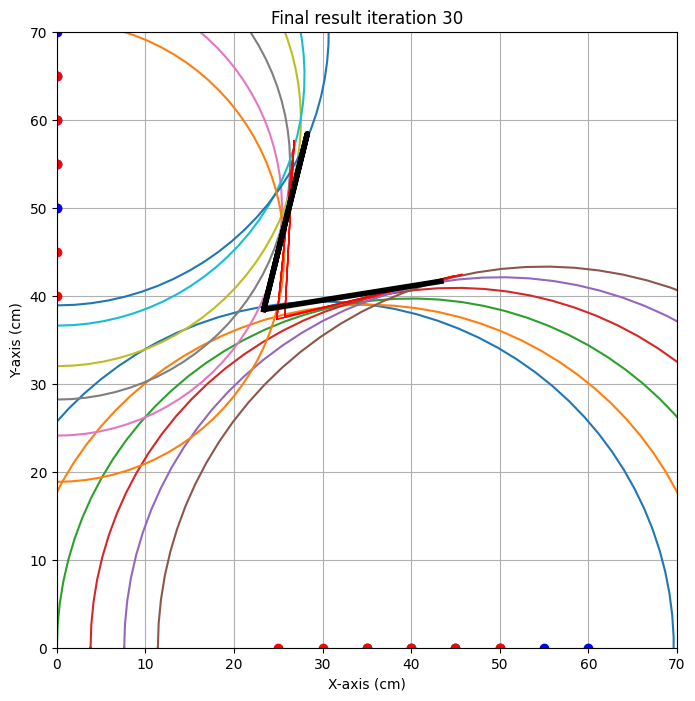

{'alpha': np.float64(9.125933332177683), 'alpha_eps': np.float64(4.718916822755304), 'beta': np.float64(13.819659708655998), 'beta_eps': np.float64(10.796704373455986), 'x0': np.float64(23.35639715997606), 'x0_eps': np.float64(2.371236913159514), 'y0': np.float64(38.43044781874216), 'y0_eps': np.float64(1.10985477323554)}
test locatie 
x0 target is : 25.0. Gevonden waarde: 23.4 cm met een standaardafwijking van 2.4 cm 
y0 target is : 39.0. Gevonden waarde: 38.4 cm met een standaardafwijking van 1.1 cm 
alpha target is : 14.0. Gevonden waarde: 9.1 graden met een standaardafwijking van 4.7 graad 
beta target is : 10.0. Gevonden waarde: 13.8 graden met een standaardafwijking van 10.8 graad 



In [13]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':25,  # zelf aanvullen,
                    'y0':39,  # zelf aanvullen,
                    'alpha' :14,  # zelf aanvullen,
                    'beta' :10,  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20, 0, 30, 0, 81.2],
    [25, 0, 35, 0, 79.3],
    [30, 0, 40, 0, 78.6],
    [35, 0, 45, 0, 80.0],
    [40, 0, 50, 0, 82.4],
    [45, 0, 55, 0, 84.8],
    [50, 0, 60, 0, 87.2],
    [0, 45, 0, 55, 51.8],
    [0, 50, 0, 60, 53.6],
    [0, 55, 0, 65, 56.0],
    [0, 60, 0, 70, 56.8],
    [0, 65, 0, 75, 62.2],
    [0, 40, 0, 50, 52.3],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Eerste algoritme: ![Alt](algoritme3.jpg "Title")


Geïtereerde algoritme: ![Alt](AlgoritmeFinal.jpg "Title")
Eerste iteratie was meer metingen op kleinere afstanden om onzekerheden weg te werken, dit bleek niet genoeg te helpen. Daarna hebben we bij iteratie 2 metingen gedaan over de hele breedte. Waarbij elke 5 centimeter een meting gedaan werd totdat er geen waarde meer uitkwam. Dit bleek te werken, hiermee is de uiteindelijke test uitgevoerd.
